# Spotify Track Popularity Machine Learning Analysis

## 1. Machine Learning Overview

### Purpose

The purpose of this notebook is to evaluate whether Spotify track popularity can be predicted using information available about the track, album, release period, genre, and artist.

The machine learning analysis extends the exploratory, statistical, and business analyses completed in the previous notebooks by testing whether the identified patterns can generalize to unseen tracks.

The primary outcome is `track_popularity`, measured on a scale from 0 to 100.

A secondary classification analysis will also evaluate whether tracks can be identified as high popularity or lower popularity using the engineered `high_popularity` target.

### Primary Predictive Question

Can Spotify track popularity be predicted from intrinsic track and release characteristics without relying on the artist's existing popularity or follower count?

### Modeling Strategy

Two feature sets will be compared throughout the analysis.

#### Model A: Intrinsic Track and Release Features

Model A evaluates whether characteristics of the track and its release context contain enough information to predict popularity.

Artist popularity and artist follower count are excluded from this model.

The feature groups include:

1. Track duration
2. Explicit content
3. Album size
4. Relative track position
5. Genre
6. Album type
7. Release period

#### Model B: Full Information Model

Model B uses the same intrinsic track and release characteristics as Model A and additionally includes:

1. Artist popularity
2. Artist follower count

The purpose of Model B is to measure how much predictive performance improves when information about the artist's existing market position is available.

Artist popularity will be interpreted cautiously because it is related to the popularity of the artist's existing tracks and therefore should not be treated as a purely intrinsic characteristic of an individual track.

### Machine Learning Tasks

Two predictive tasks will be performed.

#### Regression

Regression will be the primary modeling task.

Target:

`track_popularity`

The regression models will be evaluated using:

1. Mean Absolute Error
2. Root Mean Squared Error
3. R² Score

The regression analysis will determine how accurately the continuous Spotify popularity score can be predicted.

#### Classification

Classification will be treated as a secondary analysis.

Target:

`high_popularity`

The classification models will evaluate whether tracks can be identified as belonging to the high popularity segment.

The classification models will be evaluated using:

1. Accuracy
2. Precision
3. Recall
4. F1 Score
5. Confusion Matrix
6. ROC AUC where appropriate

Because the high popularity target may be imbalanced, accuracy will not be interpreted independently. Greater emphasis will be placed on precision, recall, F1 score, and performance relative to a baseline classifier.

### Leakage Prevention

The dataset contains cases where the same underlying song may appear more than once because of alternative releases, albums, or Spotify track identifiers.

To reduce the risk of information leakage, tracks will be grouped using the combination of track name and artist name.

The train and test datasets will then be created so that the same song group cannot appear in both datasets.

This provides a more realistic evaluation of how well the models generalize to unseen songs.

### Model Evaluation Principle

Every predictive model will be compared against a simple baseline model.

A machine learning model will only be considered useful if it provides meaningful improvement over the corresponding baseline.

Model performance will also be interpreted together with the statistical findings and business context established in the earlier stages of the project.

### Business Objective

The final objective is not simply to identify the model with the highest score.

The analysis aims to determine:

1. Whether intrinsic track and release characteristics contain meaningful predictive information
2. How much artist level information improves prediction
3. Which features contribute most strongly to predictive performance
4. Whether the predictive performance is sufficiently strong to support practical music strategy decisions
5. What limitations stakeholders should consider when using the results


## 2. Import Libraries

In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

## 3. Load and Validate the Engineered Dataset

### Purpose

The purpose of this section is to load the final dataset produced during feature engineering and confirm that it is ready for machine learning.

Before building any predictive model, the dataset will be checked for:

1. Dataset dimensions
2. Available variables
3. Data types
4. Missing values
5. Regression and classification targets
6. Features created during feature engineering

These checks ensure that the machine learning analysis uses the intended variables and does not accidentally introduce missing data, inappropriate predictors, or target leakage.


In [214]:
from pathlib import Path

PROJECT_ROOT = Path.home() / "Documents" / "spotify_project"
CLEAN_DATA = PROJECT_ROOT / "data" / "clean"

list(CLEAN_DATA.glob("*.csv"))

[PosixPath('/Users/jannoelvero/Documents/spotify_project/data/clean/spotify_final.csv'),
 PosixPath('/Users/jannoelvero/Documents/spotify_project/data/clean/spotify_features.csv'),
 PosixPath('/Users/jannoelvero/Documents/spotify_project/data/clean/spotify_mysql.csv')]

### 3.1 Load the Feature Engineered Dataset

The `spotify_features.csv` dataset is loaded as the candidate modeling dataset because it contains the features prepared during the feature engineering stage.

Before using it for machine learning, its structure and contents will be validated to confirm that the expected target variables and engineered predictors are present.


In [217]:
features_path = CLEAN_DATA / "spotify_features.csv"

df = pd.read_csv(features_path)

df.shape

(8775, 23)

In [219]:
df.columns.tolist()

['track_id',
 'track_name',
 'track_number',
 'track_popularity',
 'explicit',
 'artist_name',
 'artist_popularity',
 'artist_followers',
 'artist_genres',
 'album_id',
 'album_name',
 'album_release_date',
 'album_total_tracks',
 'album_type',
 'track_duration_min',
 'release_year',
 'track_group',
 'primary_genre',
 'genre_grouped',
 'relative_track_position',
 'release_decade',
 'log_artist_followers',
 'high_popularity']

In [218]:
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,...,album_type,track_duration_min,release_year,track_group,primary_genre,genre_grouped,relative_track_position,release_decade,log_artist_followers,high_popularity
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,False,Britney Spears,80.0,17755451.0,pop,325wcm5wMnlfjmKZ8PXIIn,...,compilation,3.55,2009,3 | britney spears,pop,pop,0.982759,2000s,16.692203,0
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,False,BUNT.,69.0,293734.0,stutter house,2ArRQNLxf9t0O0gvmG5Vsj,...,single,2.65,2023,clouds | bunt.,stutter house,Other,1.000000,2020s,12.590433,0
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,False,Taylor Swift,100.0,145396321.0,Unknown,4hDok0OAJd57SGIT8xuWJH,...,album,3.76,2021,forever & always (taylor’s version) | taylor s...,Unknown,Unknown,0.423077,2020s,18.794974,0
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,True,Billie Eilish,90.0,118692183.0,Unknown,0JGOiO34nwfUdDrD612dOp,...,album,2.64,2021,i didn't change my number | billie eilish,Unknown,Unknown,0.125000,2020s,18.592044,1
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,False,Rihanna,90.0,68997177.0,Unknown,5QG3tjE5L9F6O2vCAPph38,...,album,4.45,2010,man down | rihanna,Unknown,Unknown,0.538462,2010s,18.049576,0


In [220]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8775 entries, 0 to 8774
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   track_id                 8775 non-null   str    
 1   track_name               8775 non-null   str    
 2   track_number             8775 non-null   int64  
 3   track_popularity         8775 non-null   int64  
 4   explicit                 8775 non-null   bool   
 5   artist_name              8773 non-null   str    
 6   artist_popularity        8772 non-null   float64
 7   artist_followers         8772 non-null   float64
 8   artist_genres            8775 non-null   str    
 9   album_id                 8775 non-null   str    
 10  album_name               8775 non-null   str    
 11  album_release_date       8775 non-null   str    
 12  album_total_tracks       8775 non-null   int64  
 13  album_type               8775 non-null   str    
 14  track_duration_min       8775 non-n

### 3.2 Validate the Modeling Dataset

The feature engineered dataset contains 8,775 observations and 23 variables.

Two target variables are available:

1. `track_popularity` is the primary continuous target for regression.
2. `high_popularity` is the secondary binary target for classification.

The dataset also contains the engineered variables required for the two model specifications.

Before creating the training and testing datasets, missing values and potential target leakage will be examined.

Variables that directly identify tracks, artists, or albums will not be used as predictors. Variables derived directly from the prediction target will also be excluded from the corresponding feature set.


In [221]:
df.isnull().sum().sort_values(ascending=False)

log_artist_followers       3
artist_popularity          3
artist_followers           3
artist_name                2
track_group                2
track_id                   0
album_type                 0
release_decade             0
relative_track_position    0
genre_grouped              0
primary_genre              0
release_year               0
track_duration_min         0
album_release_date         0
album_total_tracks         0
track_name                 0
album_name                 0
album_id                   0
artist_genres              0
explicit                   0
track_popularity           0
track_number               0
high_popularity            0
dtype: int64

In [222]:
df[df["track_group"].isnull()]

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,...,album_type,track_duration_min,release_year,track_group,primary_genre,genre_grouped,relative_track_position,release_decade,log_artist_followers,high_popularity
1395,2NbsBSshscKIPRG3kwBbfo,Never Felt So Alone,1,68,False,NaN,NaN,NaN,Unknown,33JqWTchq6piiQddrRIvJX,...,single,2.67,2023,NaN,Unknown,Unknown,1.0,2020s,NaN,0
3883,5EhZC8GFOVXrpiUW22jncE,Urban Twilight,4,30,False,NaN,NaN,NaN,Unknown,1Cog6aZ6NwnJiuINc0LQEU,...,single,4.26,2011,NaN,Unknown,Unknown,0.8,2010s,NaN,0


### 3.3 Investigate Missing Artist Information

Missing values are limited to a very small number of artist related variables.

Two observations are missing `artist_name` and consequently do not have a valid `track_group`. Three observations are missing artist popularity, follower count, and the logarithmic follower feature.

Because the number of missing artist metric values is slightly larger than the number of missing artist names, the affected observations will be examined before determining how they should be handled.

This prevents observations from being removed automatically without first understanding the source and structure of the missing data.


In [223]:
missing_artist_info = df[
    df["artist_popularity"].isnull() |
    df["artist_followers"].isnull() |
    df["artist_name"].isnull()
]

missing_artist_info[
    [
        "track_id",
        "track_name",
        "artist_name",
        "artist_popularity",
        "artist_followers",
        "track_group",
        "track_popularity"
    ]
]

,track_id,track_name,artist_name,artist_popularity,artist_followers,track_group,track_popularity
436,3QhfFRPkhPCR1RMJWV1gde,Radio,Lana Del Rey,NaN,NaN,radio | lana del rey,65
1395,2NbsBSshscKIPRG3kwBbfo,Never Felt So Alone,NaN,NaN,NaN,NaN,68
3883,5EhZC8GFOVXrpiUW22jncE,Urban Twilight,NaN,NaN,NaN,NaN,30


### 3.4 Prepare the Final Modeling Dataset

Three observations contain incomplete artist information.

One observation has an identified artist but is missing artist popularity and follower information. Two additional observations are missing the artist name, artist metrics, and the `track_group` required for the group based train and test split.

These three observations represent only a very small proportion of the dataset. They will therefore be removed from the modeling dataset rather than imputing artificial values for artist popularity or follower count.

Using the same complete observations for Model A and Model B also ensures that differences in model performance are caused by the additional artist level predictors rather than differences in the observations used by each model.


In [224]:
model_df = df.dropna(
    subset=[
        "artist_name",
        "artist_popularity",
        "artist_followers",
        "log_artist_followers",
        "track_group"
    ]
).copy()

model_df.shape

(8772, 23)

In [225]:
model_df[
    [
        "artist_name",
        "artist_popularity",
        "artist_followers",
        "log_artist_followers",
        "track_group"
    ]
].isnull().sum()

artist_name             0
artist_popularity       0
artist_followers        0
log_artist_followers    0
track_group             0
dtype: int64

In [226]:
removed_rows = len(df) - len(model_df)

print("Original observations:", len(df))
print("Modeling observations:", len(model_df))
print("Removed observations:", removed_rows)
print("Percentage removed:", round(removed_rows / len(df) * 100, 3), "%")

Original observations: 8775
Modeling observations: 8772
Removed observations: 3
Percentage removed: 0.034 %


## 4. Target Variable Validation

### Purpose

The machine learning analysis uses two target variables representing different predictive tasks.

The primary target is `track_popularity`, which measures Spotify track popularity on a continuous scale from 0 to 100 and will be used for regression.

The secondary target is `high_popularity`, a binary variable created during feature engineering and will be used for classification.

Before model development, both targets are examined to confirm their distributions and ensure that the classification target is interpreted correctly.

This step is important because the distribution of the target influences model selection, baseline performance, evaluation metrics, and the interpretation of predictive results.


### 4.1 Regression Target: Track Popularity

The primary machine learning target is `track_popularity`.

Because this variable is continuous, regression models will be used to predict the actual popularity score rather than assigning tracks to a predefined category.

The distribution and descriptive statistics of the target are examined before modeling.


In [227]:
model_df["track_popularity"].describe()

count    8772.000000
mean       52.250000
std        24.061921
min         0.000000
25%        39.000000
50%        58.000000
75%        71.000000
max       100.000000
Name: track_popularity, dtype: float64

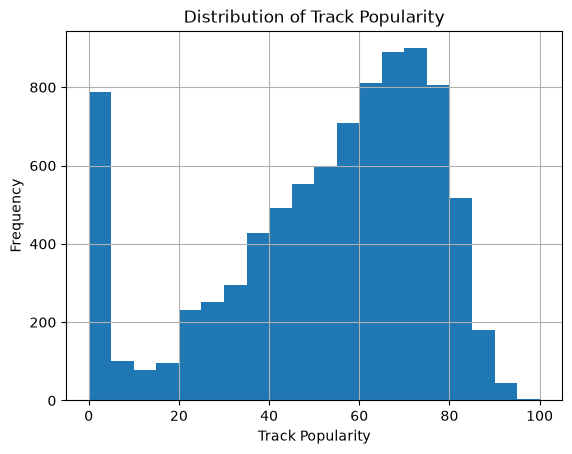

In [228]:
model_df["track_popularity"].hist(bins=20)

plt.xlabel("Track Popularity")
plt.ylabel("Frequency")
plt.title("Distribution of Track Popularity")
plt.show()

### 4.2 Classification Target: High Popularity

The secondary machine learning target is `high_popularity`.

This variable converts track popularity into two classes for the classification analysis:

`0` represents the lower popularity group.

`1` represents the high popularity group.

The class distribution is examined before modeling because an unequal distribution can make accuracy misleading. The classification models will therefore be compared with a baseline classifier and evaluated using precision, recall, F1 score, and other appropriate metrics in addition to accuracy.


In [229]:
model_df["high_popularity"].value_counts()

high_popularity
0    6509
1    2263
Name: count, dtype: int64

In [230]:
model_df["high_popularity"].value_counts(normalize=True).mul(100).round(2)

high_popularity
0    74.2
1    25.8
Name: proportion, dtype: float64

In [231]:
model_df.groupby("high_popularity")["track_popularity"].agg(
    ["count", "min", "max", "mean", "median"]
)

,count,min,max,mean,median
high_popularity,,,,,
0,6509,0,70,43.407897,49.0
1,2263,71,100,77.682280,77.0


### Target Validation Findings

The classification target contains 6,509 lower popularity tracks and 2,263 high popularity tracks. This corresponds to approximately 74.2% and 25.8% of the modeling dataset, respectively.

The high popularity category begins at a track popularity score of 71. Tracks with scores from 0 to 70 are classified as lower popularity, while tracks with scores from 71 to 100 are classified as high popularity.

The class distribution is moderately imbalanced. A model that predicts every observation as the majority class could therefore achieve approximately 74.2% accuracy without successfully identifying any high popularity tracks.

For this reason, classification accuracy will not be evaluated independently. Precision, recall, F1 score, and performance relative to a baseline classifier will be particularly important when evaluating the high popularity class.

The relationship between the two target variables also confirms an important leakage risk. Because `high_popularity` is directly derived from `track_popularity`, it must not be used as a predictor in the regression analysis. Similarly, `track_popularity` must not be used as a predictor in the classification analysis.


## 5. Feature Selection and Leakage Prevention

### Purpose

The purpose of this section is to define the predictor variables used by the machine learning models while preventing target leakage and inappropriate identity based prediction.

The predictors are divided into two feature sets so that the analysis can distinguish between information contained in the track and release characteristics and information associated with the artist's existing market position.

### Model A: Intrinsic Track and Release Features

Model A uses characteristics associated with the track and its release context:

1. Track duration
2. Album size
3. Relative track position
4. Explicit content
5. Grouped genre
6. Album type
7. Release decade

Artist popularity and follower information are deliberately excluded.

This model addresses the primary business question of whether track and release characteristics contain sufficient information to predict popularity without relying on the artist's existing market position.

### Model B: Full Information Model

Model B contains all Model A predictors and additionally includes:

1. Artist popularity
2. Log transformed artist followers

The logarithmic follower feature is used instead of the original follower count because the follower distribution was strongly skewed during the earlier analysis.

Comparing Model A and Model B allows the incremental predictive value of artist level information to be measured.

### Excluded Variables

Identifiers and descriptive variables such as track ID, track name, artist name, album ID, and album name are excluded because they identify specific observations rather than representing generalizable track characteristics.

Variables that duplicate information already represented by selected engineered features are also excluded where appropriate.

Most importantly, variables derived from the prediction target are never used as predictors. `high_popularity` is excluded from regression because it is derived directly from `track_popularity`, while `track_popularity` is excluded from classification.


In [232]:
model_a_features = [
    "track_duration_min",
    "album_total_tracks",
    "relative_track_position",
    "explicit",
    "genre_grouped",
    "album_type",
    "release_decade"
]

model_a_features

['track_duration_min',
 'album_total_tracks',
 'relative_track_position',
 'explicit',
 'genre_grouped',
 'album_type',
 'release_decade']

In [233]:
model_b_features = model_a_features + [
    "artist_popularity",
    "log_artist_followers"
]

model_b_features

['track_duration_min',
 'album_total_tracks',
 'relative_track_position',
 'explicit',
 'genre_grouped',
 'album_type',
 'release_decade',
 'artist_popularity',
 'log_artist_followers']

In [234]:
numeric_a = [
    "track_duration_min",
    "album_total_tracks",
    "relative_track_position"
]

categorical_a = [
    "explicit",
    "genre_grouped",
    "album_type",
    "release_decade"
]

In [235]:
numeric_b = numeric_a + [
    "artist_popularity",
    "log_artist_followers"
]

categorical_b = categorical_a.copy()

In [236]:
print("Model A missing values:")
print(model_df[model_a_features].isnull().sum())

print("\nModel B missing values:")
print(model_df[model_b_features].isnull().sum())

Model A missing values:
track_duration_min         0
album_total_tracks         0
relative_track_position    0
explicit                   0
genre_grouped              0
album_type                 0
release_decade             0
dtype: int64

Model B missing values:
track_duration_min         0
album_total_tracks         0
relative_track_position    0
explicit                   0
genre_grouped              0
album_type                 0
release_decade             0
artist_popularity          0
log_artist_followers       0
dtype: int64


## 6. Leakage Safe Train and Test Split

### Purpose

The purpose of the train and test split is to evaluate how well the machine learning models generalize to observations that were not used during model training.

A conventional random row split could create information leakage in this dataset because the same underlying song may appear more than once under different Spotify track IDs, albums, or releases.

To reduce this risk, the existing `track_group` variable is used to keep observations representing the same song together.

### Method

A group based train and test split is performed using `GroupShuffleSplit`.

Approximately 80% of the observations will be assigned to the training set and 20% to the testing set.

The split is based on `track_group` rather than individual rows. Therefore, the exact proportion of observations may differ slightly from 80% and 20%.

The same split will be used for both Model A and Model B and for the regression and classification analyses. This ensures that model performance can be compared using exactly the same training and testing observations.

The test set will remain separate from model training and will be used for final holdout evaluation.


In [237]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        model_df,
        groups=model_df["track_group"]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

In [238]:
print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

print(
    "Training percentage:",
    round(len(train_df) / len(model_df) * 100, 2),
    "%"
)

print(
    "Testing percentage:",
    round(len(test_df) / len(model_df) * 100, 2),
    "%"
)

Training observations: 7014
Testing observations: 1758
Training percentage: 79.96 %
Testing percentage: 20.04 %


In [239]:
train_groups = set(train_df["track_group"])
test_groups = set(test_df["track_group"])

overlap = train_groups.intersection(test_groups)

print("Unique training song groups:", len(train_groups))
print("Unique testing song groups:", len(test_groups))
print("Song groups appearing in both sets:", len(overlap))

Unique training song groups: 6334
Unique testing song groups: 1584
Song groups appearing in both sets: 0


In [240]:
print("Training track popularity:")
print(train_df["track_popularity"].describe())

print("\nTesting track popularity:")
print(test_df["track_popularity"].describe())

Training track popularity:
count    7014.000000
mean       52.114058
std        24.108318
min         0.000000
25%        39.000000
50%        58.000000
75%        71.000000
max        99.000000
Name: track_popularity, dtype: float64

Testing track popularity:
count    1758.000000
mean       52.792378
std        23.875021
min         0.000000
25%        40.000000
50%        58.000000
75%        71.000000
max       100.000000
Name: track_popularity, dtype: float64


In [241]:
print("Training class distribution:")
print(
    train_df["high_popularity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting class distribution:")
print(
    test_df["high_popularity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training class distribution:
high_popularity
0    74.31
1    25.69
Name: proportion, dtype: float64

Testing class distribution:
high_popularity
0    73.78
1    26.22
Name: proportion, dtype: float64


### Train and Test Split Findings

The group based split produced 7,014 training observations and 1,758 testing observations, corresponding to approximately 80% and 20% of the modeling dataset.

The training set contains 6,334 unique song groups, while the test set contains 1,584 unique song groups. No song group appears in both datasets, confirming that the group based split successfully prevents the same underlying song from contributing information to both model training and final evaluation.

The regression target is also well balanced across the two datasets. Mean track popularity is 52.11 in the training set and 52.79 in the test set, while both datasets have a median popularity score of 58. Their quartiles and standard deviations are also very similar.

The classification target shows comparable distributions. High popularity tracks represent 25.69% of the training data and 26.22% of the testing data.

These results indicate that the group based split successfully prevents song level overlap while maintaining comparable target distributions between the training and testing datasets. The split will therefore be retained for all subsequent regression and classification models.


## 7. Regression Modeling

### Purpose

Regression is the primary predictive analysis because `track_popularity` is measured on a continuous scale from 0 to 100.

The objective is to determine how accurately track popularity can be predicted and whether adding artist level information produces meaningful improvement over models based only on intrinsic track and release characteristics.

All regression models will be evaluated on the same unseen test set using:

1. Mean Absolute Error
2. Root Mean Squared Error
3. R² Score

Lower MAE and RMSE values indicate better predictive accuracy, while a higher R² indicates that the model explains more variation in track popularity.

### 7.1 Baseline Regression Model

Before evaluating machine learning models, a simple baseline is required.

A `DummyRegressor` using the mean strategy predicts the average training popularity score for every observation regardless of its characteristics.

The baseline represents the level of predictive performance that a machine learning model must improve upon to demonstrate that the predictor variables contain useful predictive information.


In [242]:
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [243]:
y_train_reg = train_df["track_popularity"]
y_test_reg = test_df["track_popularity"]

print("Training target:", y_train_reg.shape)
print("Testing target:", y_test_reg.shape)

Training target: (7014,)
Testing target: (1758,)


In [244]:
X_train_a = train_df[model_a_features]
X_test_a = test_df[model_a_features]

dummy_reg = DummyRegressor(strategy="mean")

dummy_reg.fit(X_train_a, y_train_reg)

dummy_pred = dummy_reg.predict(X_test_a)

In [247]:
dummy_mae = mean_absolute_error(
    y_test_reg,
    dummy_pred
)

dummy_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        dummy_pred
    )
)

dummy_r2 = r2_score(
    y_test_reg,
    dummy_pred
)

print("Baseline MAE:", round(dummy_mae, 3))
print("Baseline RMSE:", round(dummy_rmse, 3))
print("Baseline R²:", round(dummy_r2, 3))

Baseline MAE: 19.346
Baseline RMSE: 23.878
Baseline R²: -0.001


### Baseline Regression Findings

The baseline model produced an MAE of **19.35**, an RMSE of **23.88**, and an R² of approximately **0.00** on the unseen test data.

#### Model Interpretation

The MAE indicates that predicting the training set mean popularity for every track results in an average absolute prediction error of approximately **19.35 popularity points**.

The higher RMSE of **23.88** indicates that some prediction errors are substantially larger. Because RMSE gives greater weight to large errors, the difference between MAE and RMSE suggests that the baseline performs particularly poorly for tracks whose popularity is far from the average.

The R² of **−0.001** is effectively zero. This is expected because the baseline does not use any track, release, or artist characteristics to explain differences in popularity.

#### Business Interpretation

The baseline establishes the minimum level of performance that the predictive models must improve upon.

A model that cannot substantially reduce the MAE and RMSE or produce a positive R² would provide little predictive advantage over simply assigning approximately the average popularity score to every track.

The subsequent models will therefore be evaluated according to how much additional predictive information they extract from the available track, release, and artist characteristics.


### 7.2 Model A: Data Preprocessing

Model A contains both numerical and categorical predictors.

The numerical variables can be used directly by the regression models, while categorical variables must first be converted into numerical representations.

One hot encoding will be applied to the categorical predictors. The encoder will be fitted using only the training data and then applied to the test data. This prevents information from the test set from influencing model preparation.

Numerical predictors will also be standardized for the Linear Regression analysis so that the preprocessing approach can be used consistently across predictors with different measurement scales.

The preprocessing transformations are learned only from the training data and subsequently applied to the unseen test data.


In [248]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [249]:
preprocessor_a = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_a
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_a
        )
    ]
)

In [250]:
X_train_a_processed = preprocessor_a.fit_transform(
    X_train_a
)

X_test_a_processed = preprocessor_a.transform(
    X_test_a
)

print("Training shape:", X_train_a_processed.shape)
print("Testing shape:", X_test_a_processed.shape)

Training shape: (7014, 45)
Testing shape: (1758, 45)


### 7.3 Model A: Linear Regression

Linear Regression is used as the first predictive model for Model A.

The model estimates track popularity using only intrinsic track and release characteristics. Artist popularity and follower information are excluded.

Linear Regression provides a simple and interpretable benchmark for determining whether the selected predictors contain meaningful linear predictive information beyond the baseline model.

Its performance will be evaluated on the unseen test set using MAE, RMSE, and R² and compared directly with the baseline regression model.


In [251]:
from sklearn.linear_model import LinearRegression

linear_a = LinearRegression()

linear_a.fit(
    X_train_a_processed,
    y_train_reg
)

linear_a_pred = linear_a.predict(
    X_test_a_processed
)

In [252]:
linear_a_mae = mean_absolute_error(
    y_test_reg,
    linear_a_pred
)

linear_a_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        linear_a_pred
    )
)

linear_a_r2 = r2_score(
    y_test_reg,
    linear_a_pred
)

print("Model A Linear Regression")
print("MAE:", round(linear_a_mae, 3))
print("RMSE:", round(linear_a_rmse, 3))
print("R²:", round(linear_a_r2, 3))

Model A Linear Regression
MAE: 17.072
RMSE: 22.025
R²: 0.148


In [253]:
print("Baseline vs Model A Linear Regression")

print(
    "MAE:",
    round(dummy_mae, 3),
    "->",
    round(linear_a_mae, 3)
)

print(
    "RMSE:",
    round(dummy_rmse, 3),
    "->",
    round(linear_a_rmse, 3)
)

print(
    "R²:",
    round(dummy_r2, 3),
    "->",
    round(linear_a_r2, 3)
)

Baseline vs Model A Linear Regression
MAE: 19.346 -> 17.072
RMSE: 23.878 -> 22.025
R²: -0.001 -> 0.148


### Model A Linear Regression Findings

Model A Linear Regression produced an MAE of **17.07**, an RMSE of **22.03**, and an R² of **0.148** on the unseen test data.

Compared with the baseline model, MAE decreased from 19.35 to 17.07 and RMSE decreased from 23.88 to 22.03. R² increased from approximately zero to 0.148.

#### Model Interpretation

The MAE indicates that the model's predicted popularity scores differ from the actual scores by approximately **17.07 popularity points on average**.

The R² of **0.148** indicates that the intrinsic track and release characteristics used in Model A explain approximately **14.8% of the variation in track popularity** within the unseen test data.

The improvement over the baseline demonstrates that these characteristics contain measurable predictive information. However, most of the variation in track popularity remains unexplained by the linear model.

#### Business Interpretation

Intrinsic characteristics such as track duration, album size, track position, explicit content, genre, album type, and release period provide some information about expected track popularity even without knowledge of the artist's existing popularity or follower base.

However, the remaining prediction error is substantial. These characteristics should therefore not be treated as sufficient for accurately forecasting the popularity of an individual track.

The result suggests that Spotify track popularity is influenced by additional factors that are not fully represented by the available intrinsic track and release characteristics.


In [254]:
mae_improvement_a = (
    (dummy_mae - linear_a_mae)
    / dummy_mae
) * 100

rmse_improvement_a = (
    (dummy_rmse - linear_a_rmse)
    / dummy_rmse
) * 100

print(
    "MAE improvement over baseline:",
    round(mae_improvement_a, 2),
    "%"
)

print(
    "RMSE improvement over baseline:",
    round(rmse_improvement_a, 2),
    "%"
)

MAE improvement over baseline: 11.76 %
RMSE improvement over baseline: 7.76 %


#### Improvement Over Baseline

Compared with the baseline model, Model A Linear Regression reduced MAE by **11.76%** and RMSE by **7.76%**.

This confirms that intrinsic track and release characteristics improve prediction beyond simply assigning the average popularity score to every track. However, the relatively modest improvement also indicates that these features alone capture only part of the information associated with track popularity.


### 7.4 Model A: Random Forest Regression

Random Forest Regression is used to test whether nonlinear relationships and interactions among the intrinsic track and release characteristics improve the prediction of track popularity.

Unlike Linear Regression, Random Forest does not assume that the relationship between each predictor and track popularity is linear. It can capture more complex patterns and interactions among variables.

The model uses the same Model A feature set and the same training and testing observations, allowing its performance to be compared directly with both the baseline and Linear Regression models.

The objective is to determine whether a more flexible modeling approach extracts additional predictive information from intrinsic track and release characteristics.


In [255]:
from sklearn.ensemble import RandomForestRegressor

In [256]:
tree_preprocessor_a = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_a
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_a
        )
    ]
)

In [257]:
X_train_a_tree = tree_preprocessor_a.fit_transform(
    X_train_a
)

X_test_a_tree = tree_preprocessor_a.transform(
    X_test_a
)

print("Training shape:", X_train_a_tree.shape)
print("Testing shape:", X_test_a_tree.shape)

Training shape: (7014, 45)
Testing shape: (1758, 45)


In [258]:
rf_a = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_a.fit(
    X_train_a_tree,
    y_train_reg
)

rf_a_pred = rf_a.predict(
    X_test_a_tree
)

In [259]:
rf_a_mae = mean_absolute_error(
    y_test_reg,
    rf_a_pred
)

rf_a_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        rf_a_pred
    )
)

rf_a_r2 = r2_score(
    y_test_reg,
    rf_a_pred
)

print("Model A Random Forest Regression")
print("MAE:", round(rf_a_mae, 3))
print("RMSE:", round(rf_a_rmse, 3))
print("R²:", round(rf_a_r2, 3))

Model A Random Forest Regression
MAE: 17.559
RMSE: 23.257
R²: 0.051


In [260]:
regression_a_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        dummy_mae,
        linear_a_mae,
        rf_a_mae
    ],
    "RMSE": [
        dummy_rmse,
        linear_a_rmse,
        rf_a_rmse
    ],
    "R2": [
        dummy_r2,
        linear_a_r2,
        rf_a_r2
    ]
})

regression_a_results.round(3)

,Model,MAE,RMSE,R2
0,Baseline,19.346,23.878,-0.001
1,Linear Regression,17.072,22.025,0.148
2,Random Forest,17.559,23.257,0.051


### Model A Regression Findings

The Model A comparison shows that both predictive models perform better than the baseline, but Linear Regression provides the strongest performance.

Linear Regression achieved an MAE of **17.07**, an RMSE of **22.03**, and an R² of **0.148**.

Random Forest Regression achieved an MAE of **17.56**, an RMSE of **23.26**, and an R² of **0.051**.

#### Model Interpretation

Linear Regression reduced the average prediction error more effectively than Random Forest and explained approximately **14.8% of the variation in track popularity** within the unseen test data.

Random Forest explained only approximately **5.1% of the variation** and produced larger MAE and RMSE values than Linear Regression.

The more flexible Random Forest model therefore did not improve predictive performance for the intrinsic feature set.

This result indicates that introducing additional model complexity does not necessarily produce better generalization. With the available intrinsic track and release characteristics, Linear Regression currently provides the strongest balance of predictive performance and model simplicity.

#### Business Interpretation

Intrinsic track and release characteristics contain measurable information about track popularity, as demonstrated by the improvement over the baseline model.

However, even the strongest Model A specification explains only a limited proportion of popularity differences across unseen songs. The average prediction error remains approximately **17 popularity points**.

This suggests that track duration, album characteristics, genre, explicit content, track position, and release period alone are insufficient for highly accurate popularity forecasting.

The next stage therefore evaluates whether adding information about the artist's existing market position substantially improves predictive performance.


### 7.5 Model B: Full Information Model

Model B extends the intrinsic feature set by adding information about the artist's existing market position.

The additional predictors are:

1. `artist_popularity`
2. `log_artist_followers`

The logarithmic follower variable is used instead of the original follower count because the original distribution is strongly skewed.

The purpose of Model B is not simply to obtain a higher prediction score. The comparison between Model A and Model B addresses an important business question: how much additional predictive information is gained when artist level market strength is available?

Artist popularity must be interpreted cautiously. Spotify artist popularity is related to the popularity of the artist's existing tracks and therefore is not considered an intrinsic characteristic of the individual track.

Model B is consequently treated as a comparison model that measures the incremental predictive value of artist information rather than as evidence that artist popularity causes track popularity.


In [261]:
X_train_b = train_df[model_b_features]
X_test_b = test_df[model_b_features]

print("Training shape:", X_train_b.shape)
print("Testing shape:", X_test_b.shape)

Training shape: (7014, 9)
Testing shape: (1758, 9)


In [262]:
preprocessor_b = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_b
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_b
        )
    ]
)

In [263]:
X_train_b_processed = preprocessor_b.fit_transform(
    X_train_b
)

X_test_b_processed = preprocessor_b.transform(
    X_test_b
)

print("Processed training shape:", X_train_b_processed.shape)
print("Processed testing shape:", X_test_b_processed.shape)

Processed training shape: (7014, 47)
Processed testing shape: (1758, 47)


### 7.6 Model B: Linear Regression

Model B Linear Regression uses the same intrinsic track and release characteristics as Model A and adds artist popularity and logarithmic artist follower count.

The purpose of this model is to quantify how much predictive performance improves when information about the artist's existing market position is included.

Because the train and test observations are identical to those used for Model A, any improvement in performance can be attributed to the additional artist level predictors rather than to differences in the data split.

The model is evaluated using the same MAE, RMSE, and R² metrics used for the baseline and Model A.


In [264]:
linear_b = LinearRegression()

linear_b.fit(
    X_train_b_processed,
    y_train_reg
)

linear_b_pred = linear_b.predict(
    X_test_b_processed
)

In [265]:
linear_b_mae = mean_absolute_error(
    y_test_reg,
    linear_b_pred
)

linear_b_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        linear_b_pred
    )
)

linear_b_r2 = r2_score(
    y_test_reg,
    linear_b_pred
)

print("Model B Linear Regression")
print("MAE:", round(linear_b_mae, 3))
print("RMSE:", round(linear_b_rmse, 3))
print("R²:", round(linear_b_r2, 3))

Model B Linear Regression
MAE: 15.311
RMSE: 20.594
R²: 0.256


In [266]:
print("Model A vs Model B Linear Regression")

print(
    "MAE:",
    round(linear_a_mae, 3),
    "->",
    round(linear_b_mae, 3)
)

print(
    "RMSE:",
    round(linear_a_rmse, 3),
    "->",
    round(linear_b_rmse, 3)
)

print(
    "R²:",
    round(linear_a_r2, 3),
    "->",
    round(linear_b_r2, 3)
)

Model A vs Model B Linear Regression
MAE: 17.072 -> 15.311
RMSE: 22.025 -> 20.594
R²: 0.148 -> 0.256


In [267]:
mae_improvement_b = (
    (linear_a_mae - linear_b_mae)
    / linear_a_mae
) * 100

rmse_improvement_b = (
    (linear_a_rmse - linear_b_rmse)
    / linear_a_rmse
) * 100

r2_increase_b = linear_b_r2 - linear_a_r2

print(
    "MAE improvement over Model A:",
    round(mae_improvement_b, 2),
    "%"
)

print(
    "RMSE improvement over Model A:",
    round(rmse_improvement_b, 2),
    "%"
)

print(
    "R² increase:",
    round(r2_increase_b, 3)
)

MAE improvement over Model A: 10.32 %
RMSE improvement over Model A: 6.5 %
R² increase: 0.107


### Model B Linear Regression Findings

Model B Linear Regression produced an MAE of **15.31**, an RMSE of **20.59**, and an R² of **0.256** on the unseen test data.

Compared with Model A Linear Regression, MAE improved from 17.07 to 15.31 and RMSE improved from 22.03 to 20.59. R² increased from 0.148 to 0.256.

#### Model Interpretation

Adding artist popularity and logarithmic artist follower count reduced MAE by **10.32%** and RMSE by **6.50%** relative to Model A.

The R² increased by **0.107**, meaning that the full information model explains substantially more variation in track popularity than the model based only on intrinsic track and release characteristics.

Model B explains approximately **25.6% of the variation in track popularity** within the unseen test data.

This provides evidence that artist level market information adds meaningful predictive value beyond the intrinsic characteristics of the track and its release.

#### Business Interpretation

The result suggests that track popularity is not determined by intrinsic track and release characteristics alone.

Information about the artist's existing market position materially improves predictive performance. This indicates that audience reach, established visibility, and broader artist level market strength are important when estimating how popular a track is likely to become.

However, the model still leaves a large proportion of popularity variation unexplained. Even with artist information included, predictions differ from actual popularity by approximately **15 popularity points on average**.

The model should therefore be interpreted as a decision support tool rather than as a precise forecasting system.

#### Business Impact

For artists, labels, and music strategy teams, the result suggests that release characteristics should be evaluated together with artist market position.

A track with favorable intrinsic characteristics may still have limited expected popularity if the artist has low existing visibility, while stronger artist market presence can materially improve the predictive outlook.

This does not imply that artist popularity causes track popularity. It shows that artist level information is strongly associated with predictive performance in this dataset.

| Model                     |        MAE |       RMSE |        R² |
| ------------------------- | ---------: | ---------: | --------: |
| Baseline                  |     19.346 |     23.878 |    -0.001 |
| Model A Linear Regression |     17.072 |     22.025 |     0.148 |
| Model A Random Forest     |     17.559 |     23.257 |     0.051 |
| Model B Linear Regression | **15.311** | **20.594** | **0.256** |



### 7.7 Model B: Random Forest Regression

Random Forest Regression is now applied to the full information feature set.

This model evaluates whether nonlinear relationships and interactions between intrinsic track characteristics and artist level information improve predictive performance beyond Model B Linear Regression.

The same training and testing observations are retained so that the results remain directly comparable with all previous regression models.


In [268]:
tree_preprocessor_b = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_b
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_b
        )
    ]
)

In [269]:
X_train_b_tree = tree_preprocessor_b.fit_transform(
    X_train_b
)

X_test_b_tree = tree_preprocessor_b.transform(
    X_test_b
)

print("Training shape:", X_train_b_tree.shape)
print("Testing shape:", X_test_b_tree.shape)

Training shape: (7014, 47)
Testing shape: (1758, 47)


In [270]:
rf_b = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_b.fit(
    X_train_b_tree,
    y_train_reg
)

rf_b_pred = rf_b.predict(
    X_test_b_tree
)

In [271]:
rf_b_mae = mean_absolute_error(
    y_test_reg,
    rf_b_pred
)

rf_b_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        rf_b_pred
    )
)

rf_b_r2 = r2_score(
    y_test_reg,
    rf_b_pred
)

print("Model B Random Forest Regression")
print("MAE:", round(rf_b_mae, 3))
print("RMSE:", round(rf_b_rmse, 3))
print("R²:", round(rf_b_r2, 3))

Model B Random Forest Regression
MAE: 14.087
RMSE: 19.649
R²: 0.322


### Model B Random Forest Findings

Model B Random Forest Regression produced an MAE of **14.09**, an RMSE of **19.65**, and an R² of **0.322** on the unseen test data.

This is the strongest regression performance obtained so far.

#### Model Interpretation

The MAE indicates that the predicted track popularity scores differ from the actual popularity scores by approximately **14.09 points on average**.

The RMSE of **19.65** remains higher than the MAE, indicating that some tracks still produce substantially larger prediction errors.

The R² of **0.322** indicates that the model explains approximately **32.2% of the variation in track popularity** within the unseen test data.

Random Forest performed considerably better under Model B than under Model A. This indicates that the addition of artist popularity and follower information provides predictive information that the Random Forest can use alongside the intrinsic track and release characteristics.

#### Business Interpretation

The result strengthens the evidence that artist level market information is important when estimating track popularity.

Intrinsic track and release characteristics alone provided limited predictive performance. When artist popularity and follower information were added, the Random Forest produced substantially more accurate predictions.

However, approximately two thirds of the variation in track popularity remains unexplained by the current feature set. Track popularity is therefore likely associated with additional factors not captured in this dataset, such as promotion, playlist exposure, audience engagement, timing, external media attention, and other market conditions.

The model should therefore support strategic assessment rather than be treated as a precise predictor of future track success.


### 7.8 Regression Model Comparison

All regression models are compared using the same leakage safe train and test split.

The comparison evaluates whether intrinsic track and release characteristics improve prediction over the baseline and how much additional performance is gained when artist level information is introduced.

Lower MAE and RMSE indicate better prediction accuracy, while higher R² indicates greater explanatory performance on the unseen test data.


In [272]:
regression_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Model A Linear Regression",
        "Model A Random Forest",
        "Model B Linear Regression",
        "Model B Random Forest"
    ],
    "MAE": [
        dummy_mae,
        linear_a_mae,
        rf_a_mae,
        linear_b_mae,
        rf_b_mae
    ],
    "RMSE": [
        dummy_rmse,
        linear_a_rmse,
        rf_a_rmse,
        linear_b_rmse,
        rf_b_rmse
    ],
    "R2": [
        dummy_r2,
        linear_a_r2,
        rf_a_r2,
        linear_b_r2,
        rf_b_r2
    ]
})

regression_results.round(3)

,Model,MAE,RMSE,R2
0,Baseline,19.346,23.878,-0.001
1,Model A Linear Regression,17.072,22.025,0.148
2,Model A Random Forest,17.559,23.257,0.051
3,Model B Linear Regression,15.311,20.594,0.256
4,Model B Random Forest,14.087,19.649,0.322


In [273]:
best_mae_improvement = (
    (dummy_mae - rf_b_mae)
    / dummy_mae
) * 100

best_rmse_improvement = (
    (dummy_rmse - rf_b_rmse)
    / dummy_rmse
) * 100

print(
    "MAE improvement over baseline:",
    round(best_mae_improvement, 2),
    "%"
)

print(
    "RMSE improvement over baseline:",
    round(best_rmse_improvement, 2),
    "%"
)

print(
    "R² improvement:",
    round(rf_b_r2 - dummy_r2, 3)
)

MAE improvement over baseline: 27.18 %
RMSE improvement over baseline: 17.71 %
R² improvement: 0.323


In [274]:
rf_mae_improvement = (
    (rf_a_mae - rf_b_mae)
    / rf_a_mae
) * 100

rf_rmse_improvement = (
    (rf_a_rmse - rf_b_rmse)
    / rf_a_rmse
) * 100

print(
    "Random Forest MAE improvement from Model A to B:",
    round(rf_mae_improvement, 2),
    "%"
)

print(
    "Random Forest RMSE improvement from Model A to B:",
    round(rf_rmse_improvement, 2),
    "%"
)

print(
    "Random Forest R²:",
    round(rf_a_r2, 3),
    "->",
    round(rf_b_r2, 3)
)

Random Forest MAE improvement from Model A to B: 19.77 %
Random Forest RMSE improvement from Model A to B: 15.51 %
Random Forest R²: 0.051 -> 0.322


### Regression Model Comparison Findings

The regression analysis shows a clear progression in predictive performance as additional information is introduced.

The baseline model produced an MAE of 19.35 and explained essentially none of the variation in track popularity.

Model A Linear Regression improved MAE to 17.07 and achieved an R² of 0.148, demonstrating that intrinsic track and release characteristics contain measurable predictive information.

Model A Random Forest did not improve upon Linear Regression, indicating that additional model complexity alone did not produce stronger generalization from the intrinsic feature set.

Adding artist level information substantially improved both modeling approaches. Model B Linear Regression achieved an MAE of 15.31 and an R² of 0.256, while Model B Random Forest achieved the strongest overall performance with an MAE of **14.09**, an RMSE of **19.65**, and an R² of **0.322**.

#### Improvement Over the Baseline

The strongest model reduced MAE by **27.18%** and RMSE by **17.71%** compared with the baseline model.

Its R² improved from approximately zero to 0.322, demonstrating that the complete feature set provides meaningful predictive information about track popularity.

#### Model A Versus Model B

The comparison between the two Random Forest models provides particularly strong evidence of the incremental predictive value of artist information because the modeling algorithm and train and test observations remain unchanged.

Adding artist popularity and logarithmic follower count reduced Random Forest MAE by **19.77%** and RMSE by **15.51%**.

R² increased from **0.051 for Model A to 0.322 for Model B**.

This substantial improvement indicates that artist level market information contributes considerably more predictive information when combined with the available track and release characteristics.

#### Business Impact

The findings suggest that intrinsic characteristics alone provide some indication of expected track popularity but are insufficient for accurate prediction.

Artist market position substantially strengthens predictive performance. For music strategy teams, this means that evaluating a release without considering the artist's existing audience and market visibility may omit important information associated with expected popularity.

At the same time, the strongest model still explains only 32.2% of the variation in popularity and has an average prediction error of approximately 14 points.

The model therefore provides useful directional information but should not be used as a standalone forecasting system. Track popularity remains influenced by substantial variation that is not captured by the available predictors.


### 7.9 Group Aware Cross Validation

The holdout test results identify Model B Random Forest as the strongest regression model. However, performance from a single train and test split may depend partly on which observations were assigned to each dataset.

Group aware cross validation is therefore used to evaluate whether the model performs consistently across multiple subsets of unseen songs.

`GroupKFold` preserves the song grouping structure during validation so that observations representing the same underlying song are not divided between training and validation folds.

Five folds are used. For each fold, the model is trained on four groups of observations and evaluated on the remaining group.

MAE, RMSE, and R² are recorded for each fold. The mean and standard deviation of these metrics are then used to assess the stability of predictive performance.


In [275]:
from sklearn.model_selection import GroupKFold

In [276]:
X_b_all = model_df[model_b_features]
y_reg_all = model_df["track_popularity"]
groups_all = model_df["track_group"]

group_kfold = GroupKFold(n_splits=5)

In [277]:
cv_mae = []
cv_rmse = []
cv_r2 = []

for train_index, val_index in group_kfold.split(
    X_b_all,
    y_reg_all,
    groups_all
):
    X_train_cv = X_b_all.iloc[train_index]
    X_val_cv = X_b_all.iloc[val_index]

    y_train_cv = y_reg_all.iloc[train_index]
    y_val_cv = y_reg_all.iloc[val_index]

    preprocessor_cv = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                numeric_b
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_b
            )
        ]
    )

    X_train_cv_processed = preprocessor_cv.fit_transform(
        X_train_cv
    )

    X_val_cv_processed = preprocessor_cv.transform(
        X_val_cv
    )

    rf_cv = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf_cv.fit(
        X_train_cv_processed,
        y_train_cv
    )

    cv_pred = rf_cv.predict(
        X_val_cv_processed
    )

    cv_mae.append(
        mean_absolute_error(
            y_val_cv,
            cv_pred
        )
    )

    cv_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_val_cv,
                cv_pred
            )
        )
    )

    cv_r2.append(
        r2_score(
            y_val_cv,
            cv_pred
        )
    )

In [278]:
cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "MAE": cv_mae,
    "RMSE": cv_rmse,
    "R2": cv_r2
})

cv_results.round(3)

,Fold,MAE,RMSE,R2
0,1,13.438,19.006,0.370
1,2,14.004,19.632,0.321
2,3,14.294,19.915,0.337
3,4,13.881,19.525,0.342
4,5,14.316,19.648,0.329


In [279]:
print(
    "Mean MAE:",
    round(np.mean(cv_mae), 3),
    "+/-",
    round(np.std(cv_mae), 3)
)

print(
    "Mean RMSE:",
    round(np.mean(cv_rmse), 3),
    "+/-",
    round(np.std(cv_rmse), 3)
)

print(
    "Mean R²:",
    round(np.mean(cv_r2), 3),
    "+/-",
    round(np.std(cv_r2), 3)
)

Mean MAE: 13.987 +/- 0.321
Mean RMSE: 19.545 +/- 0.299
Mean R²: 0.34 +/- 0.017


### Cross Validation Findings

The five fold group aware cross validation results show that Model B Random Forest performs consistently across different groups of unseen songs.

Across the five folds, MAE ranged from **13.44 to 14.32**, RMSE ranged from **19.01 to 19.92**, and R² ranged from **0.321 to 0.370**.

The average cross validation performance was:

* **MAE: 13.99 ± 0.32**
* **RMSE: 19.55 ± 0.30**
* **R²: 0.340 ± 0.017**

#### Model Stability

The relatively small standard deviations indicate that predictive performance is stable across the five validation folds.

These results are also closely aligned with the original holdout test results of MAE 14.09, RMSE 19.65, and R² 0.322.

The consistency between the holdout test and group aware cross validation strengthens confidence that the performance of Model B Random Forest is not dependent on one favorable train and test split.

Because song groups were kept separate between training and validation observations, the results also provide stronger evidence that the model can generalize to song groups that were not used during training.

#### Business Interpretation

Model B Random Forest demonstrates reproducible predictive value across different subsets of the dataset.

The model consistently predicts track popularity with an average absolute error of approximately **14 popularity points** and explains approximately **one third of the variation in popularity** across the cross validation folds.

This level of performance supports the model's use for directional analysis and comparative decision support. However, the remaining prediction error and unexplained variation indicate that the model should not be treated as a precise forecasting system for individual tracks.


### 7.10 Regression Prediction Diagnostics

Model B Random Forest is selected for further diagnostic analysis because it achieved the strongest holdout performance and demonstrated stable results under group aware cross validation.

Model diagnostics are used to investigate how prediction errors behave rather than relying only on aggregate performance metrics.

The analysis examines:

1. Actual versus predicted popularity
2. Residual behavior
3. Prediction error across popularity levels
4. Tracks with the largest prediction errors

These diagnostics help identify systematic model limitations and determine where predictions should be interpreted cautiously.


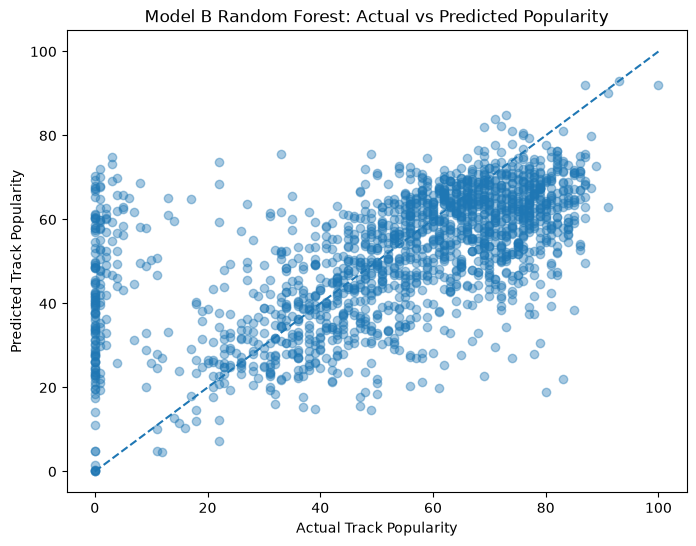

In [280]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    rf_b_pred,
    alpha=0.4
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Actual Track Popularity")
plt.ylabel("Predicted Track Popularity")
plt.title(
    "Model B Random Forest: Actual vs Predicted Popularity"
)

plt.show()

#### Actual Versus Predicted Popularity

The actual versus predicted plot shows a clear positive relationship between observed and predicted track popularity, confirming that the model captures meaningful predictive structure.

However, the predictions are compressed toward the middle of the popularity range.

Tracks with very low actual popularity are frequently **overpredicted**, while many tracks with high actual popularity are **underpredicted**. Predictions for tracks in the middle of the popularity distribution generally appear closer to the perfect prediction line.

This pattern indicates that Model B Random Forest is more effective at estimating moderate popularity levels than extreme outcomes.

#### Model Limitation

The concentration of predictions toward the center suggests that the model has difficulty distinguishing tracks at the extremes of the popularity distribution.

This is particularly important from a business perspective because the most commercially relevant cases may include unusually successful tracks. A model that systematically underestimates these observations may be useful for general directional assessment while remaining less reliable for identifying exceptionally popular tracks.

Similarly, the substantial overprediction observed among some very low popularity tracks indicates that the model may assign moderate expected popularity to tracks that ultimately perform poorly.

The model should therefore be interpreted cautiously when predictions concern the extreme ends of the popularity scale.


### 7.11 Residual Analysis

Residual analysis is used to examine the direction and magnitude of the prediction errors produced by Model B Random Forest.

Residuals are calculated as actual popularity minus predicted popularity.

A positive residual indicates that the model underpredicted the track's popularity, while a negative residual indicates that the model overpredicted its popularity.

Examining the residual distribution helps determine whether prediction errors are centered around zero and whether substantial errors remain in either direction.


In [281]:
residuals = y_test_reg - rf_b_pred

print("Mean residual:", round(residuals.mean(), 3))
print("Median residual:", round(np.median(residuals), 3))
print("Residual standard deviation:", round(residuals.std(), 3))
print("Minimum residual:", round(residuals.min(), 3))
print("Maximum residual:", round(residuals.max(), 3))

Mean residual: 0.945
Median residual: 3.437
Residual standard deviation: 19.632
Minimum residual: -71.94
Maximum residual: 60.99


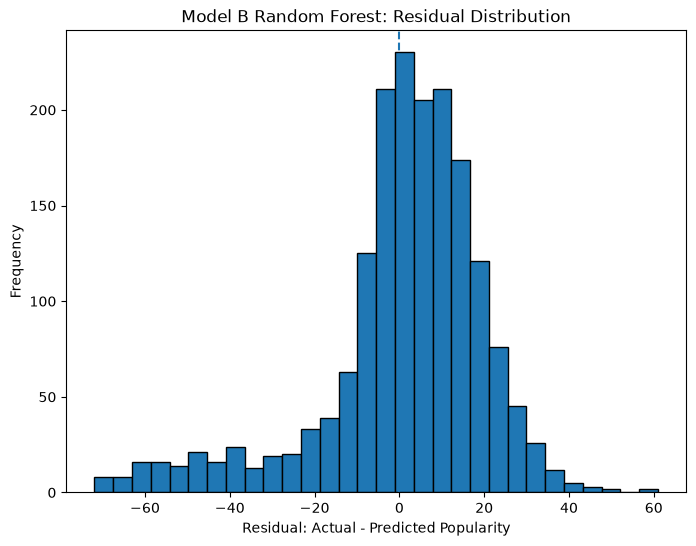

In [282]:
plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual: Actual - Predicted Popularity")
plt.ylabel("Frequency")
plt.title(
    "Model B Random Forest: Residual Distribution"
)

plt.show()

#### Residual Distribution Findings

The residual analysis provides additional evidence about the prediction behavior of Model B Random Forest.

The mean residual is **0.95**, which is relatively close to zero. This indicates that the model does not show substantial overall directional bias across the complete test set.

The median residual is **3.44**, indicating that the typical residual is slightly positive. Since residuals are calculated as actual popularity minus predicted popularity, this suggests a tendency toward modest underprediction for a typical observation.

However, the residual standard deviation is **19.63**, showing considerable variation in prediction errors.

The residuals range from **−71.94 to +60.99**. These extreme values demonstrate that although the model performs reasonably on average, individual tracks can still have very large prediction errors.

#### Interpretation

The residual results should be considered together with the actual versus predicted plot.

The small mean residual does not imply that the model is equally accurate across all popularity levels. Positive and negative prediction errors can offset each other when averaged.

The earlier diagnostic plot showed that very low popularity tracks are frequently overpredicted, while highly popular tracks are often underpredicted. The residual distribution confirms that substantial errors occur in both directions.

This reinforces the conclusion that Model B Random Forest is more suitable for general directional assessment than precise prediction of individual track popularity.


### 7.12 Prediction Error by Popularity Level

The previous diagnostics suggest that prediction errors may differ across the popularity distribution.

To investigate this pattern quantitatively, actual track popularity is divided into popularity ranges. For each range, the analysis compares actual and predicted popularity and calculates the average residual and absolute prediction error.

This allows the analysis to determine whether the model systematically overpredicts or underpredicts particular popularity levels and whether prediction accuracy changes across the target distribution.


In [283]:
error_analysis = test_df[
    [
        "track_name",
        "artist_name",
        "track_popularity"
    ]
].copy()

error_analysis["predicted_popularity"] = rf_b_pred

error_analysis["residual"] = (
    error_analysis["track_popularity"]
    - error_analysis["predicted_popularity"]
)

error_analysis["absolute_error"] = (
    error_analysis["residual"].abs()
)

In [284]:
error_analysis["popularity_range"] = pd.cut(
    error_analysis["track_popularity"],
    bins=[-1, 20, 40, 60, 80, 100],
    labels=[
        "0-20",
        "21-40",
        "41-60",
        "61-80",
        "81-100"
    ]
)

In [285]:
error_by_popularity = (
    error_analysis
    .groupby(
        "popularity_range",
        observed=True
    )
    .agg(
        tracks=("track_popularity", "size"),
        mean_actual=("track_popularity", "mean"),
        mean_predicted=("predicted_popularity", "mean"),
        mean_residual=("residual", "mean"),
        mean_absolute_error=("absolute_error", "mean")
    )
    .round(2)
)

error_by_popularity

,tracks,mean_actual,mean_predicted,mean_residual,mean_absolute_error
popularity_range,,,,,
0-20,212,3.57,40.73,-37.16,37.48
21-40,238,32.21,35.68,-3.47,9.12
41-60,489,51.32,49.39,1.93,8.79
61-80,696,70.37,60.22,10.15,11.47
81-100,123,83.87,64.70,19.17,19.25


### Prediction Error by Popularity Level Findings

Prediction accuracy varies substantially across different levels of actual track popularity.

Tracks in the **0–20 popularity range** show the largest prediction error. Their average actual popularity is 3.57, while the model predicts an average of 40.73. The mean residual of **−37.16** indicates substantial systematic overprediction, with an MAE of **37.48**.

Performance improves considerably for tracks in the middle of the popularity distribution. Tracks with popularity between **21–40** have an MAE of 9.12, while tracks between **41–60** have the lowest MAE at **8.79**.

For tracks between **61–80**, the mean residual increases to **+10.15**, indicating systematic underprediction.

The pattern becomes stronger for the most popular tracks. Tracks in the **81–100 range** have an average actual popularity of 83.87 but an average predicted popularity of only 64.70. The resulting mean residual of **+19.17** confirms substantial underprediction among highly popular tracks.

#### Diagnostic Conclusion

The results confirm that Model B Random Forest systematically compresses predictions toward moderate popularity values.

The model substantially overpredicts tracks at the lowest end of the popularity distribution and increasingly underpredicts tracks as actual popularity becomes high.

Prediction accuracy is strongest in the middle ranges, particularly between 21 and 60 popularity points.

This means that the overall MAE of approximately 14 points does not fully describe model performance. Prediction reliability depends strongly on where a track falls within the actual popularity distribution.

#### Business Implication

This limitation is particularly relevant when using the model to identify exceptionally successful or unsuccessful tracks.

The model is considerably more reliable for estimating moderate popularity than for identifying extreme outcomes. It may underestimate the potential of highly popular tracks while assigning unrealistically high predictions to some very low popularity tracks.

The model should therefore be used primarily for directional and comparative analysis rather than as a precise forecasting tool for extreme popularity outcomes.


### 7.13 Largest Prediction Errors

Aggregate error metrics can conceal individual observations for which the model performs particularly poorly.

The tracks with the largest absolute prediction errors are therefore examined to identify whether the extreme errors share common characteristics or reveal additional limitations in the model.

This analysis is diagnostic rather than causal. Its purpose is to identify unusual prediction cases that may require further investigation.


In [286]:
largest_errors = (
    error_analysis
    .sort_values(
        "absolute_error",
        ascending=False
    )
    [
        [
            "track_name",
            "artist_name",
            "track_popularity",
            "predicted_popularity",
            "residual",
            "absolute_error"
        ]
    ]
    .head(15)
)

largest_errors.round(2)

,track_name,artist_name,track_popularity,predicted_popularity,residual,absolute_error
4664,Bring Me To Life,Evanescence,3,74.94,-71.94,71.94
2428,Boyfriend,Justin Bieber,1,71.96,-70.96,70.96
3101,It's My Life,Bon Jovi,3,73.30,-70.30,70.30
7245,BELIEVE IT,PARTYNEXTDOOR,0,70.28,-70.28,70.28
4524,Dangerous Woman,Ariana Grande,0,69.49,-69.49,69.49
7234,She Keeps Me Up,Nickelback,1,70.19,-69.19,69.19
3286,Calling (Spider-Man: Across the Spider-Verse) ...,Metro Boomin,0,67.86,-67.86,67.86
4587,Baby,Justin Bieber,0,67.53,-67.53,67.53
3841,Linger,The Cranberries,0,67.31,-67.31,67.31
1893,Don't Cry (Original),Guns N' Roses,1,67.96,-66.96,66.96


### Largest Prediction Error Findings

The largest prediction errors reveal a notable pattern.

All 15 of the largest errors involve tracks with recorded popularity scores between **0 and 4**, while the model predicts popularity values between approximately **65 and 75**.

Several of these observations are associated with artists that have substantial artist level popularity and follower information in the dataset. Because Model B incorporates these artist characteristics, the model assigns considerably higher predicted popularity than the recorded track popularity values.

#### Analytical Concern

These observations should not immediately be interpreted as simple model failures.

The concentration of extremely low track popularity values among otherwise strong artist profiles raises a potential target validity or data quality question.

Spotify track popularity is associated with a specific track record and may vary across releases or versions. Therefore, a low popularity value may represent a legitimate observation for the specific track ID collected rather than an incorrect value.

The extreme errors nevertheless warrant further investigation because they contribute substantially to the poor predictive performance observed in the lowest popularity range.

Before drawing conclusions about model behavior at the lower extreme, the characteristics of these observations should be examined more closely.


### 7.14 Investigation of Extreme Low Popularity Records

The largest prediction errors are concentrated among tracks with extremely low recorded popularity despite relatively high model predictions.

To determine whether this pattern reflects legitimate observations, unusual track versions, or a broader limitation in the target variable, the underlying records are examined in greater detail.

This investigation does not assume that the observations are incorrect. The objective is to understand why the model and the recorded popularity values differ so substantially.


In [287]:
extreme_low = test_df.loc[
    largest_errors.index,
    [
        "track_id",
        "track_name",
        "artist_name",
        "track_popularity",
        "artist_popularity",
        "artist_followers",
        "album_name",
        "album_type",
        "album_release_date",
        "release_year"
    ]
].copy()

extreme_low["predicted_popularity"] = rf_b_pred[
    test_df.index.get_indexer(extreme_low.index)
]

extreme_low.round(2)

,track_id,track_name,artist_name,track_popularity,artist_popularity,artist_followers,album_name,album_type,album_release_date,release_year,predicted_popularity
4664,646J2jOtUe4Jflrmh6JFjN,Bring Me To Life,Evanescence,3,75.0,6161997.0,Fallen,album,2003-01-01,2003,74.94
2428,0171XsIM2xyeXRr6wsugEI,Boyfriend,Justin Bieber,1,91.0,85008100.0,Believe,album,2012-01-01,2012,71.96
3101,1zOaxkbS1kAY1gIi0g8sOm,It's My Life,Bon Jovi,3,78.0,15801991.0,Crush,album,2000-06-13,2000,73.30
7245,4HDCLYli2SUdkq9OjmvhSD,BELIEVE IT,PARTYNEXTDOOR,0,83.0,10115734.0,PARTYMOBILE,album,2020-03-27,2020,70.28
4524,2h1IPjP471JJRSShTHRUhi,Dangerous Woman,Ariana Grande,0,90.0,107389514.0,Dangerous Woman,album,2016-05-20,2016,69.49
7234,6I0ivNW5YryeC3GQn56NAy,She Keeps Me Up,Nickelback,1,78.0,7849274.0,No Fixed Address,album,2014-11-17,2014,70.19
3286,0by9UaVYUrKUz2TVAmK0Pg,Calling (Spider-Man: Across the Spider-Verse) ...,Metro Boomin,0,84.0,11679132.0,METRO BOOMIN PRESENTS SPIDER-MAN: ACROSS THE S...,album,2023-06-05,2023,67.86
4587,2eJ8ij1T3cNUKiGdcUvKhy,Baby,Justin Bieber,0,91.0,85022258.0,My Worlds (International Version),album,2010-01-01,2010,67.53
3841,1aLNpg2kKvUncflV8xE5AA,Linger,The Cranberries,0,76.0,5401129.0,"Everybody Else Is Doing It, So Why Can't We? (...",album,1993-03-01,1993,67.31
1893,0ZEhlT9v8CdOKu55zhYGv9,Don't Cry (Original),Guns N' Roses,1,80.0,35196831.0,Use Your Illusion I,album,1991-09-17,1991,67.96


In [288]:
extreme_track_names = largest_errors[
    "track_name"
].unique()

duplicate_versions = (
    model_df[
        model_df["track_name"].isin(
            extreme_track_names
        )
    ]
    [
        [
            "track_id",
            "track_name",
            "artist_name",
            "album_name",
            "album_release_date",
            "track_popularity"
        ]
    ]
    .sort_values(
        [
            "track_name",
            "track_popularity"
        ],
        ascending=[True, False]
    )
)

duplicate_versions

,track_id,track_name,artist_name,album_name,album_release_date,track_popularity
7245,4HDCLYli2SUdkq9OjmvhSD,BELIEVE IT,PARTYNEXTDOOR,PARTYMOBILE,2020-03-27,0
4594,6epn3r7S14KUqlReYr77hA,Baby,Justin Bieber,My World 2.0,2010-01-01,83
5585,1i6mTfj9Nn2bYMsrkdqdSc,Baby,Helena Deland,Drawing Room,2016-07-11,35
4587,2eJ8ij1T3cNUKiGdcUvKhy,Baby,Justin Bieber,My Worlds (International Version),2010-01-01,0
53,2RSHsoi04658QL5xgQVov3,Bad Liar,Imagine Dragons,Origins (Deluxe),2018-11-09,80
3832,1sCxVKWImDZSZKvG0U9B23,Bad Liar,Selena Gomez,Bad Liar,2017-05-18,0
1635,59CfNbkERJ3NoTXDvoURjj,Boyfriend,Dove Cameron,Boyfriend,2022-02-11,71
5308,4QnC1bIaMSfDQvF4XDhV5M,Boyfriend,Selena Gomez,Rare (Deluxe),2020-04-09,49
2428,0171XsIM2xyeXRr6wsugEI,Boyfriend,Justin Bieber,Believe,2012-01-01,1
7014,0COqiPhxzoWICwFCS4eZcp,Bring Me To Life,Evanescence,Fallen,2003-03-04,87


### Extreme Error Investigation Findings

The investigation of the largest prediction errors identified an important characteristic of the dataset.

Several songs appear under multiple Spotify track IDs or releases with substantially different recorded popularity values.

For example, different records of the same song show large popularity differences:

* *Bring Me To Life*: 87 versus 3
* *Baby*: 83 versus 0
* *Calling*: 70 versus 0
* *Dangerous Woman*: 80, 66, and 0
* *God's Plan*: 83 versus 1
* *Leave The Door Open*: 69, 3, and 0
* *exes*: 83 versus 4

These observations indicate that song title and artist identity do not necessarily correspond to a single popularity value. Different Spotify track IDs, album releases, or versions of the same song can have substantially different recorded popularity values.

#### Implication for Model Error

This finding helps explain some of the extreme prediction errors observed in Model B Random Forest.

The model uses artist market information and release characteristics but does not contain a feature that fully distinguishes why one Spotify record of a song receives very low popularity while another record of the same song receives high popularity.

As a result, some observations that initially appeared to represent severe model failures may instead reflect variation at the Spotify track ID or release level that is not captured by the available predictors.

#### Data Quality Interpretation

The low popularity observations should not automatically be classified as incorrect data.

Instead, they reveal an important limitation of the target variable and dataset structure: popularity is associated with a specific Spotify track record rather than necessarily representing a stable popularity measure for the underlying song.

This distinction is important when interpreting both model performance and business implications.


#### Refined Interpretation of Low Popularity Errors

The model substantially overpredicts many observations in the lowest recorded popularity range. However, further investigation shows that some of these observations represent alternate Spotify track IDs or releases of songs that also appear elsewhere in the dataset with much higher popularity values.

Therefore, the unusually large errors at the lower end should not be attributed solely to model weakness.

Part of the error reflects variation in popularity across different Spotify records of the same underlying song that is not fully represented by the available predictors.

The diagnostic findings therefore identify both a **model limitation** and a **data granularity limitation**.


### 7.15 Permutation Feature Importance

Permutation importance is used to evaluate which predictors contribute most strongly to the performance of Model B Random Forest.

For each feature, its values are randomly shuffled while the other features remain unchanged. The resulting decrease in model performance indicates how much predictive information the model was obtaining from that feature.

Permutation importance is calculated on the held out test data rather than the training data. This focuses the interpretation on the model's ability to generalize to unseen song groups.

The analysis evaluates the original Model B predictors rather than individual one hot encoded categories, allowing the importance of each business relevant feature to be interpreted directly.

Feature importance represents predictive contribution within this model and should not be interpreted as evidence of causation.


In [289]:
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

In [290]:
rf_b_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor_b
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_b_pipeline.fit(
    X_train_b,
    y_train_reg
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['track_duration_min','album_total_tracks','relative_track_position',..., 'release_decade','artist_popularity','log_artist_followers']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data pa

In [291]:
permutation_result = permutation_importance(
    rf_b_pipeline,
    X_test_b,
    y_test_reg,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [293]:
feature_importance = pd.DataFrame({
    "Feature": model_b_features,
    "Importance": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.round(3)

,Feature,Importance,Std
0,artist_popularity,7.709,0.204
1,album_total_tracks,2.314,0.108
2,log_artist_followers,2.100,0.118
3,release_decade,0.905,0.088
4,genre_grouped,0.834,0.072
5,track_duration_min,0.519,0.081
6,relative_track_position,0.414,0.077
7,album_type,0.184,0.040
8,explicit,0.077,0.052


### Permutation Feature Importance Findings

Permutation importance shows that the predictors do not contribute equally to Model B Random Forest.

`artist_popularity` is the most important predictor by a substantial margin, with an importance value of **7.709**. This means that randomly disrupting artist popularity increased the model's test MAE by approximately 7.71 points on average, indicating that the model relies heavily on this variable for accurate predictions.

The next most important predictors are `album_total_tracks` at **2.314** and `log_artist_followers` at **2.100**.

Release decade and grouped genre provide additional predictive information, with importance values of **0.905** and **0.834**, respectively.

Track duration and relative track position make smaller contributions, while album type and explicit status have the lowest permutation importance among the predictors included in Model B.

#### Feature Ranking

1. `artist_popularity`: 7.709
2. `album_total_tracks`: 2.314
3. `log_artist_followers`: 2.100
4. `release_decade`: 0.905
5. `genre_grouped`: 0.834
6. `track_duration_min`: 0.519
7. `relative_track_position`: 0.414
8. `album_type`: 0.184
9. `explicit`: 0.077

#### Model Interpretation

The feature importance results reinforce the earlier comparison between Model A and Model B.

Artist level information, particularly artist popularity, contributes substantially to the predictive performance of the full information model. This helps explain why Model B considerably outperformed Model A.

However, permutation importance measures how useful a feature is to this fitted model. It does not establish that changing the feature would cause track popularity to change.

The relatively low importance of variables such as explicit status or album type also does not mean that these characteristics have no relationship with popularity. It means that disrupting them produces relatively little deterioration in this model's predictive performance after the other predictors are already available.


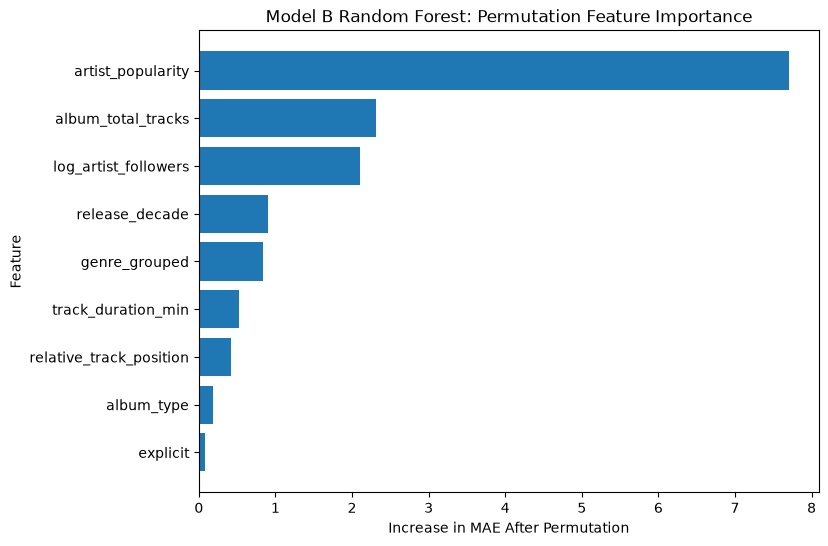

In [294]:
plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Increase in MAE After Permutation")
plt.ylabel("Feature")
plt.title(
    "Model B Random Forest: Permutation Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

#### Business Interpretation

Artist popularity is the dominant predictive feature in Model B, followed by album size and artist follower information.

This suggests that predictions of track popularity become considerably stronger when information about the artist's existing market position is available.

Track and release characteristics still contribute predictive information, particularly album size, release period, and genre, but their individual contributions are substantially smaller than that of artist popularity.

For music strategy teams, the results support evaluating track characteristics within the broader context of artist market position rather than treating the characteristics of a release in isolation.


### 7.17 Album Size and Track Popularity Investigation

Permutation importance identified `album_total_tracks` as the second most important predictor in Model B Random Forest.

Because feature importance does not reveal the direction or shape of a relationship, album size is investigated further before drawing a business conclusion.

The analysis examines how track popularity varies across different album sizes and whether the relationship appears linear or nonlinear.

The results are interpreted as associations rather than causal effects.

In [295]:
model_df["album_total_tracks"].describe()

count    8772.000000
mean       13.784656
std        11.798629
min         1.000000
25%         6.000000
50%        13.000000
75%        17.000000
max       181.000000
Name: album_total_tracks, dtype: float64

In [296]:
model_df["album_total_tracks"].value_counts().head(20)

album_total_tracks
1     1647
12     692
16     549
13     543
14     512
11     470
17     458
15     454
10     424
18     307
20     222
19     206
2      196
22     177
21     151
9      136
3      132
23     128
26     111
24     109
Name: count, dtype: int64

In [297]:
print(
    "Minimum album size:",
    model_df["album_total_tracks"].min()
)

print(
    "Maximum album size:",
    model_df["album_total_tracks"].max()
)

print(
    "Unique album sizes:",
    model_df["album_total_tracks"].nunique()
)

Minimum album size: 1
Maximum album size: 181
Unique album sizes: 82


#### Album Size Distribution

Album size varies substantially across the dataset.

The median release contains 13 tracks, while the mean is slightly higher at 13.78 tracks. The distribution extends from 1 to 181 tracks, indicating a substantial right tail.

Single track releases are particularly common, with 1,647 observations containing exactly one track.

Because album size is highly uneven and includes unusually large releases, the relationship with track popularity should not be evaluated using the raw mean alone. Album size groups are therefore used to examine whether popularity changes nonlinearly across different release sizes.

In [298]:
model_df["album_size_group"] = pd.cut(
    model_df["album_total_tracks"],
    bins=[0, 1, 5, 10, 15, 20, 30, np.inf],
    labels=[
        "1",
        "2-5",
        "6-10",
        "11-15",
        "16-20",
        "21-30",
        "31+"
    ]
)

In [299]:
model_df["album_size_group"].value_counts().sort_index()

album_size_group
1        1647
2-5       498
6-10      799
11-15    2671
16-20    1742
21-30     948
31+       467
Name: count, dtype: int64

In [300]:
album_size_analysis = (
    model_df
    .groupby(
        "album_size_group",
        observed=True
    )
    .agg(
        tracks=("track_popularity", "size"),
        mean_popularity=("track_popularity", "mean"),
        median_popularity=("track_popularity", "median"),
        std_popularity=("track_popularity", "std")
    )
    .round(2)
)

album_size_analysis

,tracks,mean_popularity,median_popularity,std_popularity
album_size_group,,,,
1,1647,46.10,51.0,26.07
2-5,498,45.69,49.0,24.39
6-10,799,53.36,60.0,25.03
11-15,2671,58.06,64.0,22.63
16-20,1742,54.72,60.0,21.99
21-30,948,51.70,56.0,21.77
31+,467,37.69,36.0,21.78


#### Album Size and Popularity Findings

Track popularity shows a nonlinear relationship with album size.

Single track releases and releases containing 2 to 5 tracks have relatively similar mean popularity scores of 46.10 and 45.69.

Average popularity increases for releases containing 6 to 10 tracks and reaches its highest level among releases containing 11 to 15 tracks, where mean popularity is 58.06 and median popularity is 64.

Beyond this range, popularity gradually declines. Releases containing 16 to 20 tracks have a mean popularity of 54.72, while those containing 21 to 30 tracks average 51.70.

The largest releases, containing more than 30 tracks, have the lowest average popularity at 37.69.

The median values generally follow the same pattern as the means, providing additional evidence that the relationship is not driven solely by a small number of extreme observations.

#### Interpretation

The relationship between album size and track popularity is not linear.

Within this dataset, moderate sized releases, particularly those containing approximately 11 to 15 tracks, are associated with higher track popularity than either very short or very large releases.

This nonlinear pattern helps explain why `album_total_tracks` provides useful predictive information to the Random Forest model. A tree based model can capture differences between ranges of album size without assuming that every additional track produces the same change in popularity.

These findings represent associations within the dataset and do not demonstrate that changing the number of tracks on a release would cause track popularity to increase or decrease.

### 7.18 Album Size and Album Type

Album size is closely related to release format. Singles, albums, and compilations may naturally contain different numbers of tracks.

Because album type may therefore influence the observed relationship between album size and popularity, the distribution of album types across album size groups is examined before interpreting album size as an independent business factor.

In [301]:
album_type_size_counts = pd.crosstab(
    model_df["album_size_group"],
    model_df["album_type"]
)

album_type_size_counts

album_type,album,compilation,single
album_size_group,,,
1,0,1,1646
2-5,6,2,490
6-10,682,12,105
11-15,2567,104,0
16-20,1553,189,0
21-30,836,110,2
31+,377,90,0


In [302]:
album_type_size_pct = pd.crosstab(
    model_df["album_size_group"],
    model_df["album_type"],
    normalize="index"
) * 100

album_type_size_pct.round(1)

album_type,album,compilation,single
album_size_group,,,
1,0.0,0.1,99.9
2-5,1.2,0.4,98.4
6-10,85.4,1.5,13.1
11-15,96.1,3.9,0.0
16-20,89.2,10.8,0.0
21-30,88.2,11.6,0.2
31+,80.7,19.3,0.0


In [303]:
album_size_type_analysis = (
    model_df
    .groupby(
        [
            "album_type",
            "album_size_group"
        ],
        observed=True
    )
    .agg(
        tracks=("track_popularity", "size"),
        mean_popularity=("track_popularity", "mean"),
        median_popularity=("track_popularity", "median")
    )
    .round(2)
)

album_size_type_analysis

tracks  mean_popularity  median_popularity
album_type  album_size_group                                            
album       2-5                    6            72.50               72.0
            6-10                 682            54.00               61.5
            11-15               2567            58.54               65.0
            16-20               1553            56.18               62.0
            21-30                836            53.57               57.0
            31+                  377            39.14               36.0
compilation 1                      1            61.00               61.0
            2-5                    2            53.50               53.5
            6-10                  12            50.92               53.5
            11-15                104            46.16               49.0
            16-20                189            42.70               45.0
            21-30                110            37.11               40.0
            31+                   90            31.60               36.5
single      1                   1646            46.09               51.0
            2-5                  490            45.33               48.0
            6-10                 105            49.54               54.0
            21-30                  2            73.00               73.0

### Album Size and Album Type Findings

Album size and album type are strongly related.

Nearly all 1-track releases are singles (99.9%), while 98.4% of releases containing 2 to 5 tracks are also classified as singles. In contrast, releases containing 11 to 15 tracks are predominantly albums (96.1%).

This confirms that part of the overall relationship between album size and popularity reflects structural differences between release formats.

However, album type does not fully explain the album-size pattern.

#### Within-Album Comparison

When the analysis is restricted to releases classified as albums, track popularity continues to vary substantially with album size.

Albums containing 6 to 10 tracks have a mean track popularity of 54.00. Popularity increases to 58.54 for albums containing 11 to 15 tracks, which is the highest mean among the album-size groups with substantial sample sizes.

Mean popularity then declines as album size increases:

- 16 to 20 tracks: 56.18
- 21 to 30 tracks: 53.57
- More than 30 tracks: 39.14

Median popularity follows a similar pattern, reaching 65 for albums containing 11 to 15 tracks before declining to 36 among albums containing more than 30 tracks.

The 2 to 5 track album category has a higher mean popularity of 72.50, but it contains only six observations. This group is therefore too small to support a reliable general conclusion.

#### Interpretation

The results indicate that the predictive importance of `album_total_tracks` cannot be attributed solely to the distinction between singles, albums, and compilations.

A nonlinear relationship remains within the album category itself. Moderate sized albums, particularly those containing 11 to 15 tracks, are associated with higher track popularity in this dataset, while very large albums are associated with substantially lower track popularity.

The pattern is also visible among compilations, where mean popularity generally declines as the number of tracks increases. However, several of the smaller compilation categories contain very few observations and should be interpreted cautiously.

These findings help explain why album size contributes more predictive information to the Random Forest than the comparatively low permutation importance of `album_type`.

| Album size |         n | Mean popularity |   Median |
| ---------- | --------: | --------------: | -------: |
| 2–5        |         6 |           72.50 |     72.0 |
| 6–10       |       682 |           54.00 |     61.5 |
| **11–15**  | **2,567** |       **58.54** | **65.0** |
| 16–20      |     1,553 |           56.18 |     62.0 |
| 21–30      |       836 |           53.57 |     57.0 |
| **31+**    |   **377** |       **39.14** | **36.0** |


### 7.19 Regression Modeling Conclusion

The regression analysis demonstrates that track popularity contains meaningful but incomplete predictive structure.

The baseline model produced an MAE of 19.35 and an RMSE of 23.88. The strongest model, Model B Random Forest, reduced these errors to an MAE of 14.09 and an RMSE of 19.65, while achieving an R² of 0.322.

Group-aware cross-validation produced similar results, with a mean MAE of 13.99, mean RMSE of 19.55, and mean R² of 0.340. This indicates that the model's performance is relatively stable across different unseen song groups within the dataset.

Comparing Model A and Model B demonstrates that artist-level market information provides substantial incremental predictive value. Artist popularity is the dominant permutation importance feature, followed by album size and artist follower information.

Model diagnostics also reveal important limitations. Predictions are most accurate for moderate popularity levels and become less reliable at the extremes. Some extreme errors are associated with multiple Spotify track IDs or releases of the same underlying song having substantially different recorded popularity values, highlighting a limitation in the granularity of the target variable.

Further investigation of album size shows a nonlinear relationship with popularity that persists even when album type is considered. Moderate sized albums are associated with higher track popularity in this dataset, while very large albums show substantially lower popularity.

Overall, Model B Random Forest provides useful directional and comparative information but should not be treated as a precise forecasting model for individual tracks. The findings represent predictive associations within this dataset and do not establish causal effects.

## 8. Classification Modeling

The secondary machine learning objective is to classify tracks into higher and lower popularity groups.

The target variable is `high_popularity`, where tracks with popularity scores of 71 or higher are classified as high popularity (`1`) and tracks below 71 are classified as lower popularity (`0`).

The threshold is derived from the dataset and is used as a reproducible analytical definition. It should not be interpreted as an official Spotify definition of a successful or hit track.

The classification analysis uses the same group-aware training and testing observations used in the regression analysis. This ensures that different Spotify records belonging to the same song group do not appear across both sets.

Because the target is moderately imbalanced, accuracy alone is not sufficient for evaluating model performance. Precision, recall, F1 score, confusion matrix, and ROC AUC will also be considered.

A majority-class baseline is established before evaluating the predictive models.

In [304]:
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [305]:
y_train_clf = train_df["high_popularity"]
y_test_clf = test_df["high_popularity"]

print("Training target:", y_train_clf.shape)
print("Testing target:", y_test_clf.shape)

Training target: (7014,)
Testing target: (1758,)


In [306]:
dummy_clf = DummyClassifier(
    strategy="most_frequent"
)

dummy_clf.fit(
    X_train_a,
    y_train_clf
)

dummy_clf_pred = dummy_clf.predict(
    X_test_a
)

In [307]:
baseline_accuracy = accuracy_score(
    y_test_clf,
    dummy_clf_pred
)

baseline_precision = precision_score(
    y_test_clf,
    dummy_clf_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test_clf,
    dummy_clf_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test_clf,
    dummy_clf_pred,
    zero_division=0
)

print(
    "Baseline Accuracy:",
    round(baseline_accuracy, 3)
)

print(
    "Baseline Precision:",
    round(baseline_precision, 3)
)

print(
    "Baseline Recall:",
    round(baseline_recall, 3)
)

print(
    "Baseline F1:",
    round(baseline_f1, 3)
)

Baseline Accuracy: 0.738
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


### 8.1 Classification Baseline Findings

The majority-class baseline achieves an accuracy of **73.8%** by predicting every observation as the lower-popularity class.

However, the baseline has precision, recall, and F1 scores of **0.00** for the high-popularity class because it does not identify any high-popularity tracks.

This demonstrates why accuracy alone is insufficient for evaluating the classification models. A useful classifier must improve its ability to identify high-popularity tracks while maintaining acceptable overall performance.

The baseline therefore establishes two important reference points:

- **Accuracy baseline:** 73.8%
- **High-popularity F1 baseline:** 0.00

In [308]:
from sklearn.ensemble import RandomForestClassifier

In [309]:
rf_clf_a = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_clf_a.fit(
    X_train_a_tree,
    y_train_clf
)

rf_clf_a_pred = rf_clf_a.predict(
    X_test_a_tree
)

rf_clf_a_prob = rf_clf_a.predict_proba(
    X_test_a_tree
)[:, 1]

In [310]:
rf_clf_a_accuracy = accuracy_score(
    y_test_clf,
    rf_clf_a_pred
)

rf_clf_a_precision = precision_score(
    y_test_clf,
    rf_clf_a_pred,
    zero_division=0
)

rf_clf_a_recall = recall_score(
    y_test_clf,
    rf_clf_a_pred,
    zero_division=0
)

rf_clf_a_f1 = f1_score(
    y_test_clf,
    rf_clf_a_pred,
    zero_division=0
)

rf_clf_a_auc = roc_auc_score(
    y_test_clf,
    rf_clf_a_prob
)

print(
    "Model A Random Forest Classification"
)

print(
    "Accuracy:",
    round(rf_clf_a_accuracy, 3)
)

print(
    "Precision:",
    round(rf_clf_a_precision, 3)
)

print(
    "Recall:",
    round(rf_clf_a_recall, 3)
)

print(
    "F1:",
    round(rf_clf_a_f1, 3)
)

print(
    "ROC AUC:",
    round(rf_clf_a_auc, 3)
)

Model A Random Forest Classification
Accuracy: 0.706
Precision: 0.403
Recall: 0.254
F1: 0.312
ROC AUC: 0.677


In [311]:
rf_clf_a_cm = confusion_matrix(
    y_test_clf,
    rf_clf_a_pred
)

rf_clf_a_cm

array([[1124,  173],
       [ 344,  117]])

### 8.2 Model A Random Forest Findings

Model A Random Forest uses only intrinsic track and release characteristics and excludes artist popularity and follower information.

The model achieves:

- Accuracy: **70.6%**
- Precision: **40.3%**
- Recall: **25.4%**
- F1 score: **0.312**
- ROC AUC: **0.677**

The overall accuracy is lower than the majority-class baseline of 73.8%. However, the baseline achieves its higher accuracy by predicting every observation as lower popularity and therefore identifies no high-popularity tracks.

Model A correctly identifies **117 of the 461** high-popularity tracks in the test set. It misses 344 high-popularity tracks and incorrectly classifies 173 lower-popularity tracks as high popularity.

The precision of 40.3% means that approximately four out of ten tracks predicted as high popularity are actually in the high-popularity class. Recall of 25.4% indicates that the model detects approximately one quarter of all high-popularity tracks.

The ROC AUC of 0.677 indicates that the model has some ability to rank high-popularity tracks above lower-popularity tracks across classification thresholds, although the discrimination is limited.

#### Interpretation

Intrinsic track and release characteristics contain useful classification signal, but they are not sufficient for strong identification of high-popularity tracks.

Model A performs substantially better than the baseline in detecting the positive class, as demonstrated by its nonzero precision, recall, and F1 score. However, this comes at the cost of lower overall accuracy and a relatively high number of missed high-popularity tracks.

The results establish an important benchmark for determining whether artist-level market information substantially improves classification performance in Model B.

In [312]:
rf_clf_b = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_clf_b.fit(
    X_train_b_tree,
    y_train_clf
)

rf_clf_b_pred = rf_clf_b.predict(
    X_test_b_tree
)

rf_clf_b_prob = rf_clf_b.predict_proba(
    X_test_b_tree
)[:, 1]

In [313]:
rf_clf_b_accuracy = accuracy_score(
    y_test_clf,
    rf_clf_b_pred
)

rf_clf_b_precision = precision_score(
    y_test_clf,
    rf_clf_b_pred,
    zero_division=0
)

rf_clf_b_recall = recall_score(
    y_test_clf,
    rf_clf_b_pred,
    zero_division=0
)

rf_clf_b_f1 = f1_score(
    y_test_clf,
    rf_clf_b_pred,
    zero_division=0
)

rf_clf_b_auc = roc_auc_score(
    y_test_clf,
    rf_clf_b_prob
)

print(
    "Model B Random Forest Classification"
)

print(
    "Accuracy:",
    round(rf_clf_b_accuracy, 3)
)

print(
    "Precision:",
    round(rf_clf_b_precision, 3)
)

print(
    "Recall:",
    round(rf_clf_b_recall, 3)
)

print(
    "F1:",
    round(rf_clf_b_f1, 3)
)

print(
    "ROC AUC:",
    round(rf_clf_b_auc, 3)
)

Model B Random Forest Classification
Accuracy: 0.758
Precision: 0.559
Recall: 0.36
F1: 0.438
ROC AUC: 0.798


In [314]:
rf_clf_b_cm = confusion_matrix(
    y_test_clf,
    rf_clf_b_pred
)

rf_clf_b_cm

array([[1166,  131],
       [ 295,  166]])

### 8.3 Model B Random Forest Findings

Model B Random Forest adds artist popularity and artist follower information to the intrinsic track and release characteristics used in Model A.

The model achieves:

- Accuracy: **75.8%**
- Precision: **55.9%**
- Recall: **36.0%**
- F1 score: **0.438**
- ROC AUC: **0.798**

The confusion matrix shows that Model B correctly classifies 1,166 lower-popularity tracks and 166 high-popularity tracks. It incorrectly classifies 131 lower-popularity tracks as high popularity and misses 295 high-popularity tracks.

Compared with Model A, Model B improves every reported evaluation metric. Accuracy increases from 70.6% to 75.8%, precision from 40.3% to 55.9%, recall from 25.4% to 36.0%, F1 from 0.312 to 0.438, and ROC AUC from 0.677 to 0.798.

Model B also exceeds the majority-class baseline accuracy of 73.8% while retaining the ability to identify high-popularity tracks.

#### Interpretation

The improvement from Model A to Model B provides further evidence that artist-level market information contributes substantial incremental predictive value.

This finding is consistent with the regression analysis, where adding artist popularity and follower information also produced a substantial improvement in predictive performance.

However, Model B still misses 295 of the 461 high-popularity tracks in the test set. Its recall of 36.0% indicates that most high-popularity observations are not identified using the default classification threshold.

Therefore, although Model B provides substantially stronger discrimination than Model A, its default predictions remain limited for applications where identifying as many potentially high-popularity tracks as possible is the primary objective.

In [315]:
classification_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Model A Random Forest",
        "Model B Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        rf_clf_a_accuracy,
        rf_clf_b_accuracy
    ],
    "Precision": [
        baseline_precision,
        rf_clf_a_precision,
        rf_clf_b_precision
    ],
    "Recall": [
        baseline_recall,
        rf_clf_a_recall,
        rf_clf_b_recall
    ],
    "F1": [
        baseline_f1,
        rf_clf_a_f1,
        rf_clf_b_f1
    ],
    "ROC_AUC": [
        0,
        rf_clf_a_auc,
        rf_clf_b_auc
    ]
})

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.738,0.000,0.000,0.000,0.000
1,Model A Random Forest,0.706,0.403,0.254,0.312,0.677
2,Model B Random Forest,0.758,0.559,0.360,0.438,0.798


In [316]:
dummy_clf_prob = dummy_clf.predict_proba(
    X_test_a
)[:, 1]

baseline_auc = roc_auc_score(
    y_test_clf,
    dummy_clf_prob
)

print(
    "Baseline ROC AUC:",
    round(baseline_auc, 3)
)

Baseline ROC AUC: 0.5


In [317]:
classification_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Model A Random Forest",
        "Model B Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        rf_clf_a_accuracy,
        rf_clf_b_accuracy
    ],
    "Precision": [
        baseline_precision,
        rf_clf_a_precision,
        rf_clf_b_precision
    ],
    "Recall": [
        baseline_recall,
        rf_clf_a_recall,
        rf_clf_b_recall
    ],
    "F1": [
        baseline_f1,
        rf_clf_a_f1,
        rf_clf_b_f1
    ],
    "ROC_AUC": [
        baseline_auc,
        rf_clf_a_auc,
        rf_clf_b_auc
    ]
})

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.738,0.000,0.000,0.000,0.500
1,Model A Random Forest,0.706,0.403,0.254,0.312,0.677
2,Model B Random Forest,0.758,0.559,0.360,0.438,0.798


### 8.4 Classification Model Comparison

The classification results show a clear improvement as additional predictive information is introduced.

The majority-class baseline achieves 73.8% accuracy but has no ability to identify high-popularity tracks. Its precision, recall, and F1 score for the high-popularity class are all zero, while its ROC AUC of 0.500 represents no discriminatory ability.

Model A Random Forest introduces intrinsic track and release characteristics. Although its accuracy falls to 70.6%, it begins identifying high-popularity tracks, achieving precision of 40.3%, recall of 25.4%, F1 of 0.312, and ROC AUC of 0.677.

Model B Random Forest produces the strongest classification performance so far. It achieves 75.8% accuracy, 55.9% precision, 36.0% recall, F1 of 0.438, and ROC AUC of 0.798.

Compared with Model A, Model B improves all reported evaluation metrics. This provides additional evidence that artist-level market information contributes substantial incremental predictive value.

Model B also improves on the majority baseline in overall accuracy while providing meaningful detection of the high-popularity class.

However, recall remains relatively low at 36.0%. Therefore, the default classification threshold still misses most high-popularity tracks.

In [318]:
from sklearn.linear_model import LogisticRegression

log_clf_b = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_clf_b.fit(
    X_train_b_processed,
    y_train_clf
)

log_clf_b_pred = log_clf_b.predict(
    X_test_b_processed
)

log_clf_b_prob = log_clf_b.predict_proba(
    X_test_b_processed
)[:, 1]

In [319]:
log_clf_b_accuracy = accuracy_score(
    y_test_clf,
    log_clf_b_pred
)

log_clf_b_precision = precision_score(
    y_test_clf,
    log_clf_b_pred,
    zero_division=0
)

log_clf_b_recall = recall_score(
    y_test_clf,
    log_clf_b_pred,
    zero_division=0
)

log_clf_b_f1 = f1_score(
    y_test_clf,
    log_clf_b_pred,
    zero_division=0
)

log_clf_b_auc = roc_auc_score(
    y_test_clf,
    log_clf_b_prob
)

print("Model B Logistic Regression")

print(
    "Accuracy:",
    round(log_clf_b_accuracy, 3)
)

print(
    "Precision:",
    round(log_clf_b_precision, 3)
)

print(
    "Recall:",
    round(log_clf_b_recall, 3)
)

print(
    "F1:",
    round(log_clf_b_f1, 3)
)

print(
    "ROC AUC:",
    round(log_clf_b_auc, 3)
)

Model B Logistic Regression
Accuracy: 0.741
Precision: 0.513
Recall: 0.249
F1: 0.336
ROC AUC: 0.772


In [320]:
log_clf_b_cm = confusion_matrix(
    y_test_clf,
    log_clf_b_pred
)

log_clf_b_cm

array([[1188,  109],
       [ 346,  115]])

### 8.5 Logistic Regression Benchmark

Logistic Regression was evaluated as a simpler benchmark using the same Model B feature set.

The model achieves:

- Accuracy: **74.1%**
- Precision: **51.3%**
- Recall: **24.9%**
- F1 score: **0.336**
- ROC AUC: **0.772**

The confusion matrix shows that Logistic Regression correctly identifies 115 of the 461 high-popularity tracks while missing 346.

Compared with Logistic Regression, Model B Random Forest performs better across all reported metrics. The largest practical improvement occurs in recall, which increases from 24.9% to 36.0%. Random Forest correctly identifies 166 high-popularity tracks, compared with 115 for Logistic Regression.

ROC AUC also increases from 0.772 to 0.798, indicating moderately stronger discrimination across classification thresholds.

#### Interpretation

The Logistic Regression results confirm that the Model B features contain substantial predictive signal even when modeled using a simpler linear decision boundary.

However, Random Forest extracts additional predictive value from these features and provides stronger identification of the high-popularity class. This is consistent with the earlier regression findings, where nonlinear relationships such as the association between album size and popularity were observed.

Model B Random Forest therefore remains the strongest classification model tested so far.

In [322]:
classification_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Model A Random Forest",
        "Model B Logistic Regression",
        "Model B Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        rf_clf_a_accuracy,
        log_clf_b_accuracy,
        rf_clf_b_accuracy
    ],
    "Precision": [
        baseline_precision,
        rf_clf_a_precision,
        log_clf_b_precision,
        rf_clf_b_precision
    ],
    "Recall": [
        baseline_recall,
        rf_clf_a_recall,
        log_clf_b_recall,
        rf_clf_b_recall
    ],
    "F1": [
        baseline_f1,
        rf_clf_a_f1,
        log_clf_b_f1,
        rf_clf_b_f1
    ],
    "ROC_AUC": [
        baseline_auc,
        rf_clf_a_auc,
        log_clf_b_auc,
        rf_clf_b_auc
    ]
})

classification_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.738,0.000,0.000,0.000,0.500
1,Model A Random Forest,0.706,0.403,0.254,0.312,0.677
2,Model B Logistic Regression,0.741,0.513,0.249,0.336,0.772
3,Model B Random Forest,0.758,0.559,0.360,0.438,0.798


### 8.7 Classification Threshold Analysis

Classification models convert predicted probabilities into class predictions using a probability threshold. By default, a threshold of 0.50 is commonly used.

However, the most appropriate threshold depends on the business objective.

For this project, failing to identify a potentially high-popularity track represents a false negative. If the business objective is to identify a broader set of promising tracks for further review, a lower classification threshold may improve recall.

This comes with a trade-off: lowering the threshold generally increases recall but may reduce precision and increase false positives.

The probability threshold is therefore investigated to understand this trade-off rather than assuming that 0.50 is automatically the most useful decision threshold.

In [323]:
thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        rf_clf_b_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test_clf,
            predictions
        ),
        "Precision": precision_score(
            y_test_clf,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_clf,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_clf,
            predictions,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df.round(3)

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.709,0.465,0.722,0.566
1,0.35,0.734,0.495,0.649,0.562
2,0.40,0.752,0.525,0.566,0.545
3,0.45,0.759,0.548,0.466,0.504
4,0.50,0.757,0.556,0.367,0.442
5,0.55,0.762,0.598,0.284,0.385
6,0.60,0.760,0.627,0.208,0.313


### Classification Threshold Findings

The threshold analysis demonstrates that the operational performance of Model B Random Forest changes substantially depending on the probability threshold used to classify a track as high popularity.

At the default threshold of 0.50, the model achieves 55.6% precision and 36.7% recall. This favors more selective positive predictions but misses a large proportion of high-popularity tracks.

Lowering the threshold substantially increases recall.

At a threshold of 0.30, recall increases to 72.2%, meaning that the model identifies more than seven out of ten high-popularity tracks in the test set. Precision decreases to 46.5%, indicating that the broader detection comes with more false positives.

The 0.30 threshold also produces the highest F1 score among the thresholds examined, at 0.566. A threshold of 0.35 produces a similar F1 score of 0.562 while providing a somewhat different balance between precision and recall.

Higher thresholds have the opposite effect. At 0.60, precision increases to 62.7%, but recall falls to only 20.8%.

#### Business Interpretation

There is no universally optimal classification threshold. The appropriate threshold depends on the cost of false positives relative to false negatives.

If the model is used as an early screening tool to identify tracks for further evaluation, a lower threshold may be appropriate because missing a potentially high-popularity track could be more costly than reviewing additional false positives.

If resources are limited and only a smaller number of higher-confidence candidates can be reviewed, a higher threshold may be preferable because it increases precision.

The threshold analysis therefore shows that predicted probabilities can support different decision strategies rather than requiring a single fixed classification rule.

In [324]:
exact_half = (rf_clf_b_prob == 0.50).sum()

different_predictions = (
    rf_clf_b_pred !=
    (rf_clf_b_prob >= 0.50).astype(int)
).sum()

print(
    "Probabilities exactly 0.50:",
    exact_half
)

print(
    "Different predictions:",
    different_predictions
)

Probabilities exactly 0.50: 7
Different predictions: 7


#### Note on the 0.50 Threshold

Seven test observations received a predicted probability of exactly 0.50.

These observations explain the small difference between the results produced by `RandomForestClassifier.predict()` and manually classifying probabilities using `probability >= 0.50`.

The difference results from how ties at exactly 0.50 are assigned rather than from a change in the underlying model.

For consistency, the original `predict()` results are retained as the official default-threshold model results. The manually applied thresholds are treated as a separate sensitivity analysis.

### 8.8 Group-Aware Cross-Validation

The holdout test set provides one estimate of classification performance. To assess whether the results are reasonably stable across different subsets of songs, Model B Random Forest is also evaluated using five-fold group-aware cross-validation.

`GroupKFold` keeps observations belonging to the same `track_group` within the same fold. This reduces the risk that different Spotify records of the same underlying song contribute to both training and validation data.

Preprocessing is fitted separately within each training fold to prevent information from the validation fold from influencing feature transformation.

The analysis evaluates accuracy, precision, recall, F1 score, and ROC AUC across the five folds.

In [325]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline

In [326]:
clf_pipeline_b = Pipeline([
    (
        "preprocessor",
        tree_preprocessor_b
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [327]:
group_kfold = GroupKFold(
    n_splits=5
)

cv_classification_results = []

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(
        model_df[model_b_features],
        model_df["high_popularity"],
        groups=model_df["track_group"]
    ),
    start=1
):

    X_train_cv = model_df[
        model_b_features
    ].iloc[train_idx]

    X_val_cv = model_df[
        model_b_features
    ].iloc[val_idx]

    y_train_cv = model_df[
        "high_popularity"
    ].iloc[train_idx]

    y_val_cv = model_df[
        "high_popularity"
    ].iloc[val_idx]

    clf_pipeline_b.fit(
        X_train_cv,
        y_train_cv
    )

    pred_cv = clf_pipeline_b.predict(
        X_val_cv
    )

    prob_cv = clf_pipeline_b.predict_proba(
        X_val_cv
    )[:, 1]

    cv_classification_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(
            y_val_cv,
            pred_cv
        ),
        "Precision": precision_score(
            y_val_cv,
            pred_cv,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val_cv,
            pred_cv,
            zero_division=0
        ),
        "F1": f1_score(
            y_val_cv,
            pred_cv,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_val_cv,
            prob_cv
        )
    })

cv_classification_df = pd.DataFrame(
    cv_classification_results
)

cv_classification_df.round(3)

,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,0.763,0.560,0.374,0.448,0.798
1,2,0.766,0.564,0.365,0.443,0.791
2,3,0.771,0.597,0.371,0.457,0.809
3,4,0.777,0.588,0.378,0.460,0.826
4,5,0.748,0.540,0.345,0.421,0.785


In [328]:
cv_classification_summary = (
    cv_classification_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
    .agg(["mean", "std"])
    .T
)

cv_classification_summary.round(3)

,mean,std
Accuracy,0.765,0.011
Precision,0.570,0.023
Recall,0.366,0.013
F1,0.446,0.015
ROC_AUC,0.802,0.016


#### Cross-Validation Results

Five-fold group-aware cross-validation produced the following average performance:

- Accuracy: **0.765 ± 0.011**
- Precision: **0.570 ± 0.023**
- Recall: **0.366 ± 0.013**
- F1 score: **0.446 ± 0.015**
- ROC AUC: **0.802 ± 0.016**

Performance varies relatively little across the five folds. ROC AUC ranges from 0.785 to 0.826, while F1 ranges from 0.421 to 0.460.

The cross-validation results are also close to the separate holdout test results for Model B Random Forest, which achieved 75.8% accuracy, 55.9% precision, 36.0% recall, an F1 score of 0.438, and ROC AUC of 0.798.

#### Interpretation

The similarity between the holdout and cross-validation results indicates that Model B's performance is reasonably stable across different unseen song groups within this dataset.

The low standard deviations provide additional evidence that the reported performance is not primarily the result of one favorable train/test split.

However, cross-validation does not remove the model's main classification limitation. Recall remains approximately 37%, meaning that at the model's default classification rule, a substantial proportion of high-popularity tracks remain unidentified.

The results support using Model B Random Forest as the strongest classification model evaluated, while recognizing that its practical use depends on the desired balance between precision and recall.

These results demonstrate stability across song groups represented in the current dataset. They should not be interpreted as evidence of performance on future releases, different time periods, or external Spotify datasets.

### 8.9 Classification Permutation Feature Importance

Permutation importance is used to investigate which original Model B features contribute most to the classifier's ability to distinguish high-popularity tracks.

Each feature is randomly shuffled while the other features remain unchanged. The resulting decrease in model performance indicates how much predictive information the fitted model was obtaining from that feature.

F1 score is used as the scoring metric because the target is moderately imbalanced and the analysis is specifically concerned with identifying the high-popularity class.

Permutation importance measures predictive contribution rather than causality. Correlated features may also share predictive information, which can affect their individual importance values.

In [329]:
clf_importance_pipeline = Pipeline([
    (
        "preprocessor",
        tree_preprocessor_b
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])

clf_importance_pipeline.fit(
    train_df[model_b_features],
    y_train_clf
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['track_duration_min','album_total_tracks','relative_track_position',..., 'release_decade','artist_popularity','log_artist_followers']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dr

In [330]:
from sklearn.inspection import permutation_importance

clf_perm_importance = permutation_importance(
    clf_importance_pipeline,
    test_df[model_b_features],
    y_test_clf,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

clf_feature_importance = pd.DataFrame({
    "Feature": model_b_features,
    "Importance": clf_perm_importance.importances_mean,
    "Std": clf_perm_importance.importances_std
})

clf_feature_importance = (
    clf_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

clf_feature_importance.round(3)

,Feature,Importance,Std
0,artist_popularity,0.132,0.016
1,album_total_tracks,0.075,0.017
2,log_artist_followers,0.058,0.012
3,genre_grouped,0.046,0.016
4,release_decade,0.040,0.015
5,relative_track_position,0.037,0.014
6,album_type,0.035,0.014
7,track_duration_min,0.011,0.014
8,explicit,0.005,0.011


#### Classification Feature Importance Findings

Permutation importance shows that `artist_popularity` is the strongest contributor to Model B's ability to identify high-popularity tracks.

Shuffling `artist_popularity` reduces F1 by approximately **0.132** on average, substantially more than any other feature.

The next most important features are:

- `album_total_tracks`: **0.075**
- `log_artist_followers`: **0.058**
- `genre_grouped`: **0.046**
- `release_decade`: **0.040**
- `relative_track_position`: **0.037**
- `album_type`: **0.035**
- `track_duration_min`: **0.011**
- `explicit`: **0.005**

The ranking is broadly consistent with the regression analysis. Artist popularity is the dominant predictor in both tasks, while album size and artist follower information also provide substantial predictive value.

Genre, release decade, track position, and album type contribute additional information to classification, although their individual importance is considerably smaller than artist popularity.

Track duration and explicit status have the lowest permutation importance. Their importance estimates are also small relative to their variability across permutation repetitions, suggesting that they provide limited independent predictive information to this fitted classifier when the other Model B features are already available.

#### Interpretation

The consistency between regression and classification strengthens the conclusion that artist market position is an important predictive component of track popularity in this dataset.

However, artist popularity should be interpreted cautiously because it is itself a market-level popularity measure rather than an intrinsic characteristic of the track. Its strong predictive contribution does not demonstrate that higher artist popularity causes an individual track to become popular.

Album size remains an important secondary predictor. This is consistent with the earlier investigation showing a nonlinear relationship between album size and track popularity that persists within the album category.

The results also show that the model is not driven exclusively by artist-level information. Release structure, genre, release period, and track position provide additional predictive information.

Permutation importance represents predictive contribution to this fitted model and should not be interpreted as causal importance.

#### Consistency Between Regression and Classification

The feature importance rankings are broadly consistent across the two predictive tasks.

In both regression and classification, the three strongest features are:

1. `artist_popularity`
2. `album_total_tracks`
3. `log_artist_followers`

Genre and release decade form the next tier of predictive information, while explicit status ranks last in both analyses.

This consistency indicates that the features contributing to prediction of the continuous popularity score are broadly similar to those helping distinguish tracks above the dataset-defined high-popularity threshold.

The agreement between the two modeling approaches provides stronger evidence that these patterns are systematic within the current dataset rather than being specific to only one target formulation or evaluation metric.

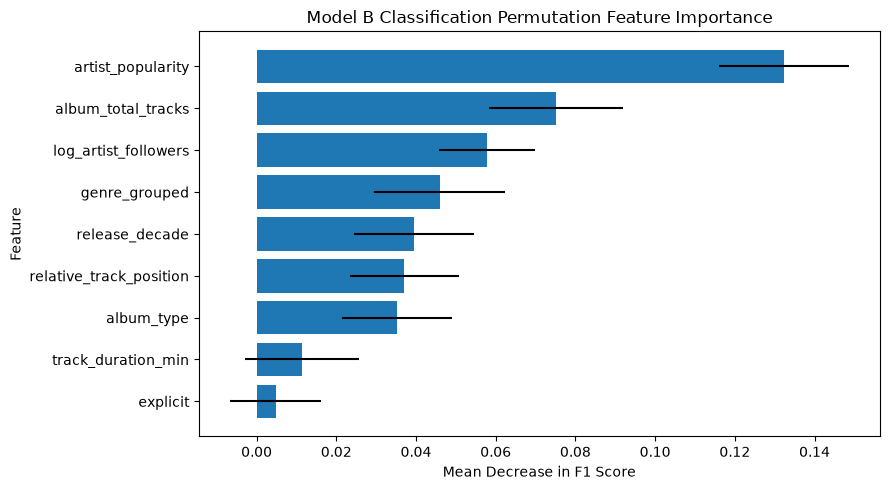

In [331]:
plt.figure(figsize=(9, 5))

plt.barh(
    clf_feature_importance["Feature"],
    clf_feature_importance["Importance"],
    xerr=clf_feature_importance["Std"]
)

plt.xlabel("Mean Decrease in F1 Score")
plt.ylabel("Feature")
plt.title(
    "Model B Classification Permutation Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The feature importance visualization highlights the dominant predictive contribution of artist popularity. Album size and artist follower information form a second tier, while the remaining track and release characteristics provide smaller incremental contributions.

Error bars represent the standard deviation across repeated permutations and provide context for the stability of each importance estimate.

### 8.11 Classification Error Analysis

Aggregate classification metrics describe overall model performance but do not explain which types of tracks are incorrectly classified.

To investigate model behavior more deeply, the test observations are divided into four prediction outcomes:

- True Negative: correctly predicted lower-popularity track
- False Positive: lower-popularity track incorrectly predicted as high popularity
- False Negative: high-popularity track incorrectly predicted as lower popularity
- True Positive: correctly predicted high-popularity track

Particular attention is given to false negatives and false positives because these errors represent different business risks.

False negatives represent high-popularity tracks that the model fails to identify, while false positives represent tracks selected by the model that do not meet the dataset-defined high-popularity threshold.

In [332]:
clf_error_analysis = test_df[
    [
        "track_name",
        "artist_name",
        "track_popularity",
        "artist_popularity",
        "log_artist_followers",
        "album_total_tracks",
        "album_type",
        "genre_grouped",
        "release_decade"
    ]
].copy()

clf_error_analysis["actual"] = (
    y_test_clf.values
)

clf_error_analysis["predicted"] = (
    rf_clf_b_pred
)

clf_error_analysis["probability"] = (
    rf_clf_b_prob
)

In [334]:
clf_error_analysis["outcome"] = np.select(
    [
        (clf_error_analysis["actual"] == 0) &
        (clf_error_analysis["predicted"] == 0),

        (clf_error_analysis["actual"] == 0) &
        (clf_error_analysis["predicted"] == 1),

        (clf_error_analysis["actual"] == 1) &
        (clf_error_analysis["predicted"] == 0),

        (clf_error_analysis["actual"] == 1) &
        (clf_error_analysis["predicted"] == 1)
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    default="Unknown"
)

In [336]:
clf_error_analysis["outcome"].value_counts()

outcome
True Negative     1166
False Negative     295
True Positive      166
False Positive     131
Name: count, dtype: int64

In [337]:
clf_outcome_summary = (
    clf_error_analysis
    .groupby("outcome")
    .agg(
        tracks=("track_name", "size"),
        mean_track_popularity=(
            "track_popularity",
            "mean"
        ),
        mean_artist_popularity=(
            "artist_popularity",
            "mean"
        ),
        mean_log_followers=(
            "log_artist_followers",
            "mean"
        ),
        mean_album_size=(
            "album_total_tracks",
            "mean"
        ),
        mean_predicted_probability=(
            "probability",
            "mean"
        )
    )
    .round(2)
)

clf_outcome_summary

,tracks,mean_track_popularity,mean_artist_popularity,mean_log_followers,mean_album_size,mean_predicted_probability
outcome,,,,,,
False Negative,295,76.83,77.94,16.13,12.86,0.31
False Positive,131,50.19,84.27,17.07,13.39,0.61
True Negative,1166,43.28,65.46,14.10,14.81,0.15
True Positive,166,78.92,84.48,17.05,13.49,0.66


#### Classification Error Analysis Findings

The error analysis reveals clear differences in the characteristics of correct and incorrect classifications.

True positives have an average track popularity of 78.92 and an average artist popularity of 84.48. False positives, however, have much lower average track popularity at 50.19 while having almost the same average artist popularity at 84.27.

Artist follower information shows a similar pattern. Mean log artist followers are 17.05 for true positives and 17.07 for false positives.

This indicates that tracks from artists with strong market profiles are more likely to receive high predicted probabilities, even when the individual track does not reach the dataset-defined high-popularity threshold.

False negatives show the opposite pattern. These tracks are genuinely high popularity, with an average track popularity of 76.83, but their average artist popularity is lower at 77.94. Their mean log artist follower value is also lower at 16.13.

This suggests that some high-popularity tracks from comparatively less established artists are more difficult for the model to identify.

True negatives have the weakest artist-level profiles overall, with average artist popularity of 65.46 and mean log artist followers of 14.10. Their mean predicted probability is correspondingly low at 0.15.

#### Predicted Probability

Mean predicted probabilities also reflect the four classification outcomes:

- True Negative: **0.15**
- False Negative: **0.31**
- False Positive: **0.61**
- True Positive: **0.66**

False positives and true positives receive relatively similar average probabilities, while false negatives remain substantially below the default decision boundary.

This pattern helps explain why artist popularity was the strongest permutation importance feature. Artist-level market position provides substantial predictive information, but it can also contribute to classification errors when the popularity of an individual track differs from the broader market position of its artist.

#### Business Interpretation

The classifier should therefore not be interpreted as an independent measure of a track's intrinsic potential.

It is partly a market-context model. Tracks from highly established artists are more likely to be classified as high popularity, while genuinely popular tracks from comparatively less established artists may be more difficult to identify.

For practical decision support, predicted probabilities should therefore complement rather than replace track-level evaluation, particularly when identifying emerging artists or unexpected breakout tracks.

### 8.12 Inspect Individual False Positives and False Negatives

In [338]:
false_positives = (
    clf_error_analysis[
        clf_error_analysis["outcome"]
        == "False Positive"
    ]
    .sort_values(
        "probability",
        ascending=False
    )
)

false_positives.head(15)

,track_name,artist_name,track_popularity,artist_popularity,log_artist_followers,album_total_tracks,album_type,genre_grouped,release_decade,actual,predicted,probability,outcome
4664,Bring Me To Life,Evanescence,3,75.0,15.633912,12,album,Other,2000s,0,1,0.920000,False Positive
4731,start a war,JENNIE,68,81.0,16.327387,15,album,k-pop,2020s,0,1,0.890000,False Positive
1948,Blank Space,Taylor Swift,59,100.0,18.794974,13,album,Unknown,2010s,0,1,0.885000,False Positive
4438,cardigan,Taylor Swift,49,100.0,18.795299,16,album,Unknown,2020s,0,1,0.835000,False Positive
6733,Wonderwall (Remastered),Oasis,2,80.0,16.332634,40,album,Other,1990s,0,1,0.825000,False Positive
8504,"thank u, next",Ariana Grande,22,90.0,18.492089,1,single,pop,2010s,0,1,0.821667,False Positive
8319,Break,Three Days Grace,70,77.0,15.803707,12,album,Other,2000s,0,1,0.810000,False Positive
4019,Rise,Jonas Blue,69,72.0,15.170762,15,album,Other,2010s,0,1,0.800000,False Positive
5181,Taste,Sabrina Carpenter,69,91.0,17.094099,12,album,pop,2020s,0,1,0.790000,False Positive
3969,Dreamcatcher (feat. Swae Lee & Travis Scott),Metro Boomin,62,84.0,16.273674,26,album,Unknown,2010s,0,1,0.775000,False Positive


In [339]:
false_negatives = (
    clf_error_analysis[
        clf_error_analysis["outcome"]
        == "False Negative"
    ]
    .sort_values(
        "probability",
        ascending=True
    )
)

false_negatives.head(15)

,track_name,artist_name,track_popularity,artist_popularity,log_artist_followers,album_total_tracks,album_type,genre_grouped,release_decade,actual,predicted,probability,outcome
1129,Crazy,Myles Lloyd,72,56.0,10.547523,1,single,Unknown,2020s,1,0,0.010000,False Negative
4309,House Of Balloons / Glass Table Girls,The Weeknd,73,93.0,18.542524,30,album,Unknown,2010s,1,0,0.010000,False Negative
3767,Watermelon,John + Jane Q. Public,72,54.0,10.955550,2,single,Unknown,2020s,1,0,0.030000,False Negative
4276,Gangnam Style (강남스타일),PSY,75,62.0,14.414151,1,single,k-pop,2010s,1,0,0.040000,False Negative
3488,You Make It Easy,Jason Aldean,76,74.0,15.768890,15,album,country,2010s,1,0,0.043333,False Negative
3427,Soaked,Shy Smith,73,56.0,12.054086,1,single,Unknown,2020s,1,0,0.050000,False Negative
4724,INDUSTRY BABY (feat. Jack Harlow),Lil Nas X,73,71.0,16.325945,1,single,Unknown,2020s,1,0,0.055000,False Negative
1200,abcdefu,GAYLE,72,58.0,13.413248,1,single,Unknown,2020s,1,0,0.055000,False Negative
5238,Telephone,Lady Gaga,78,88.0,17.559271,22,album,art pop,2000s,1,0,0.060000,False Negative
8550,Imagination,Shawn Mendes,73,81.0,17.637842,16,album,Unknown,2010s,1,0,0.061667,False Negative


#### Individual Classification Error Patterns

Inspection of the highest-confidence classification errors provides further evidence that artist-level market position strongly influences the model's predictions.

Several high-confidence false positives belong to highly established artists. These tracks receive high predicted probabilities despite their individual track popularity remaining below the high-popularity threshold.

This is consistent with the aggregate error analysis, where false positives and true positives have nearly identical average artist popularity and follower profiles.

The strongest false negatives reveal a different pattern. Several genuinely high-popularity tracks with very low predicted probabilities belong to artists with comparatively lower artist popularity and follower levels. This suggests that the model can under-identify successful tracks when strong artist-level market signals are absent.

However, this pattern is not universal. Some false negatives also belong to highly established artists. Therefore, artist market position explains an important part of the model's error structure but does not fully account for individual classification errors.

Some classification errors may also reflect the track-record granularity identified during the regression analysis. Popularity is attached to specific Spotify track records, while different releases or versions of the same underlying song can have substantially different popularity values.

#### Model Limitation

Model B therefore appears better suited to identifying tracks whose popularity is consistent with broader artist and release characteristics than to identifying unexpected outcomes.

Two practically important failure modes remain:

1. **Established-artist false positives:** strong artist-level signals can contribute to high predicted probabilities for individual tracks that remain below the popularity threshold.
2. **Unexpected-success false negatives:** tracks can achieve high popularity despite weaker or otherwise atypical predictor profiles.

This limits the model's suitability as a standalone system for identifying emerging or unexpected breakout tracks.

The model should instead be interpreted as a decision-support tool that estimates popularity potential from observable market and release characteristics while recognizing that individual track outcomes can depart substantially from those patterns.

### 8.13 Classification Modeling Conclusion

The classification analysis examined whether tracks could be distinguished as high popularity using a dataset-defined threshold of 71 or higher.

The majority-class baseline achieved 73.8% accuracy but identified no high-popularity tracks, demonstrating why accuracy alone is insufficient for this moderately imbalanced target.

Model A Random Forest, using only intrinsic track and release characteristics, achieved 70.6% accuracy, an F1 score of 0.312, and ROC AUC of 0.677. Although its accuracy was below the majority baseline, it demonstrated that intrinsic characteristics contain some useful information for identifying high-popularity tracks.

Adding artist-level market information substantially improved performance. Model B Random Forest achieved:

- Accuracy: **75.8%**
- Precision: **55.9%**
- Recall: **36.0%**
- F1 score: **0.438**
- ROC AUC: **0.798**

Model B also outperformed the Logistic Regression benchmark across all reported metrics.

Five-fold group-aware cross-validation produced similar results, with mean accuracy of 76.5%, F1 of 0.446, and ROC AUC of 0.802. The relatively small variation across folds indicates that performance is reasonably stable across unseen song groups represented in this dataset.

Permutation importance identified `artist_popularity` as the strongest classification predictor, followed by `album_total_tracks` and `log_artist_followers`. This ranking is highly consistent with the regression analysis.

Classification error analysis revealed an important limitation. False positives tend to have artist-level profiles similar to true positives, while false negatives generally have weaker artist-level market signals than correctly identified high-popularity tracks. This suggests that the classifier is more effective at recognizing popularity that is consistent with established market patterns than unexpected high-performing tracks.

The threshold sensitivity analysis also demonstrated that recall can be increased substantially by lowering the classification threshold, although this reduces precision. An operational threshold should therefore be selected according to business costs and objectives using training or validation data rather than optimized on the final test set.

Finally, converting continuous popularity into a binary target introduces an artificial boundary. Tracks immediately below and above the threshold may be very similar despite belonging to different classes. For this reason, classification is treated as a secondary decision-support analysis, while regression remains the primary predictive formulation.

## 9. Integrated Machine Learning Findings

Regression and classification provide complementary perspectives on Spotify track popularity.

Regression estimates the continuous popularity score and preserves differences across the full 0 to 100 scale. Classification simplifies the problem into identifying tracks that meet the dataset-defined high-popularity threshold.

Across both approaches, several findings are consistent.

### 1. Artist Market Position Provides the Strongest Predictive Information

Adding artist popularity and follower information substantially improves both regression and classification performance.

For regression, Model B Random Forest achieves an MAE of 14.09, RMSE of 19.65, and R² of 0.322, substantially outperforming the baseline and Model A.

For classification, Model B Random Forest achieves 75.8% accuracy, F1 of 0.438, and ROC AUC of 0.798, outperforming both Model A and the simpler Logistic Regression benchmark.

Artist popularity is also the strongest permutation importance feature in both predictive tasks.

This demonstrates that broader artist market position contains substantial predictive information about individual track popularity within the dataset.

However, artist-level variables are market-context measures rather than intrinsic track characteristics and should not be interpreted as causal drivers.

### 2. Intrinsic Track and Release Characteristics Provide Useful but Limited Predictive Signal

Model A performs better than the regression baseline but explains only a limited proportion of variation in continuous popularity.

In classification, Model A can identify some high-popularity tracks but does not exceed the majority baseline in overall accuracy.

This indicates that track and release characteristics contain meaningful predictive information but are insufficient for strong popularity prediction when used without artist-level context.

### 3. Album Size Provides Important Nonlinear Information

Album size is the second strongest permutation importance feature in both regression and classification.

Further investigation shows that its relationship with popularity is nonlinear and cannot be explained solely by album type.

Among albums with substantial sample sizes, tracks from releases containing 11 to 15 tracks show the highest average popularity, while tracks from very large albums show substantially lower popularity.

This is an observational association and does not establish that changing album length will cause popularity to increase or decrease.

### 4. The Models Are More Reliable for Pattern-Consistent Outcomes Than Exceptions

Regression predictions are compressed toward the middle of the popularity distribution. Very low popularity tracks tend to be overpredicted, while very high popularity tracks tend to be underpredicted.

Classification shows a related limitation. Tracks from highly established artists can receive high predicted probabilities even when their individual popularity is below the classification threshold. Conversely, some genuinely high-popularity tracks receive low predicted probabilities when their characteristics differ from typical high-popularity patterns.

The models therefore provide stronger support for identifying broad patterns than for predicting unusual or breakout outcomes.

### 5. Popularity Contains Important Information Not Captured by the Available Features

Even the strongest regression model explains approximately one third of the observed variation in track popularity.

The remaining variation may reflect factors not represented in the dataset, such as playlist exposure, marketing activity, social media momentum, audience behavior, timing, geographic effects, or other market dynamics.

These are plausible omitted factors rather than effects demonstrated by the current analysis.

The dataset also contains different Spotify track records or releases of the same underlying song with substantially different popularity values. This creates additional target-level complexity that the available predictors cannot fully explain.

### 6. Predictive Performance Is Stable Within the Current Dataset

Group-aware cross-validation produces results close to the holdout test performance for both regression and classification.

This provides evidence that the models are reasonably stable across different song groups represented in the dataset.

However, these results do not establish performance on future releases, different time periods, or external Spotify datasets.

### 9.1 Business Implications

The machine learning analysis suggests that popularity prediction is most useful as a decision-support process rather than as an automated forecast of whether an individual track will succeed.

#### Artist Context Matters

Artist market position provides the strongest predictive information. Release planning and performance benchmarking should therefore consider the existing audience and market position of the artist rather than evaluating every track against the same expectations.

#### Release Structure Provides Additional Context

Album size, genre, release period, and track position contribute additional predictive information. These characteristics can help refine release analysis, although they should not be interpreted as guaranteed drivers of popularity.

#### Emerging and Unexpected Success Requires Additional Evaluation

The classifier is less effective at identifying high-performing tracks that do not resemble historically typical high-popularity observations.

For emerging artists and unusual breakout tracks, model predictions should therefore be supplemented with additional indicators such as recent engagement, playlist momentum, marketing response, and other current market signals when such data are available.

#### Use Probabilities for Prioritization Rather Than Automatic Decisions

Classification probabilities can be used to prioritize tracks for further review. The appropriate probability threshold depends on whether the business values broader discovery or higher-confidence selection.

A lower threshold can identify more potentially high-popularity tracks but requires reviewing more false positives. A higher threshold produces a smaller, more selective candidate set but increases the risk of missing successful tracks.

#### Maintain Human and Market Context

The models capture historical associations within the available dataset. They should support, rather than replace, creative judgment, market expertise, and current audience intelligence.

## 10. Final Machine Learning Summary

The machine learning analysis evaluated Spotify track popularity using two complementary approaches: regression for predicting continuous popularity scores and classification for identifying tracks with high popularity.

### Regression

The strongest regression model is **Model B Random Forest**, which combines track and release characteristics with artist-level market information.

**Holdout performance:**

- MAE: **14.09**
- RMSE: **19.65**
- R²: **0.322**

**Five-fold group-aware cross-validation:**

- MAE: **13.99 ± 0.32**
- RMSE: **19.55 ± 0.30**
- R²: **0.340 ± 0.017**

Compared with the baseline, the final regression model reduces MAE by approximately **27.2%** and RMSE by approximately **17.7%**.

The model provides meaningful predictive improvement but remains better suited to directional and comparative analysis than precise prediction of individual track popularity.

### Classification

The strongest classification model is also **Model B Random Forest**.

**Holdout performance:**

- Accuracy: **75.8%**
- Precision: **55.9%**
- Recall: **36.0%**
- F1 score: **0.438**
- ROC AUC: **0.798**

**Five-fold group-aware cross-validation:**

- Accuracy: **76.5% ± 1.1 percentage points**
- Precision: **57.0% ± 2.3 percentage points**
- Recall: **36.6% ± 1.3 percentage points**
- F1 score: **0.446 ± 0.015**
- ROC AUC: **0.802 ± 0.016**

The classifier provides useful discrimination between higher and lower popularity tracks, but the default classification rule misses a substantial proportion of high-popularity observations.

Threshold sensitivity analysis demonstrates that this trade-off can be adjusted depending on whether the business prioritizes broader discovery or more selective identification.

### Key Predictive Findings

Across both regression and classification, the three strongest predictive features are:

1. **Artist popularity**
2. **Album total tracks**
3. **Artist follower information**

Artist market position provides the largest incremental predictive value. Album size also contributes substantial information and shows a nonlinear relationship with popularity.

Genre, release decade, track position, album type, and duration provide smaller additional contributions, while explicit status provides little independent predictive information in the final models.

### Overall Conclusion

Spotify track popularity is partially predictable from the available artist, track, album, genre, and release characteristics, but substantial unexplained variation remains.

The models are strongest at identifying popularity patterns that are consistent with broader artist and release characteristics. They are less reliable for extreme popularity values and unexpected high-performing tracks.

The findings therefore support using machine learning as a **decision-support and prioritization tool rather than a deterministic predictor of track success**.

Artist and release context can help identify patterns and prioritize opportunities, but model outputs should be combined with current market signals, audience behavior, and professional judgment.

All predictive findings represent associations within the current dataset. They do not establish causal relationships or guarantee performance on future or external Spotify data.

Business objective → leakage prevention → group-aware split → regression baseline → Model A → Model B → algorithm comparison → cross-validation → diagnostics → error investigation → feature importance → album-size investigation → classification baseline → Model A → Model B → Logistic Regression → threshold analysis → cross-validation → feature importance → error analysis → integrated business implications → final summary.